# Pipeline SARIMAX — grupo 5

Ouro — preço semanal

Previsão móvel de um passo (semana) com SARIMAX, a partir da base tratada publicada para todo o grupo. A estrutura de tarefas é a mesma do grupo 4; o que muda é a base, o alvo, as exógenas e o período sazonal.


### Informações do Grupo

##### Grupo: 5

Base: `base-tratada-5.xlsx` (`gold.daily.prices.csv`)

Série semanal (sextas-feiras) do preço do ouro. O alvo é `VALUE`.

- Granularidade: semanal
- Variável-alvo: `VALUE` (USD/onça)
- Random State (seed): `42`
- Treino-teste: 75% / 25%, respeitando a ordem temporal
- Horizonte: 1 semana à frente
- Sazonalidade do modelo: nenhuma componente sazonal no modelo


## Importações e Configurações Padrão

In [1]:
from pathlib import Path
import gc
import itertools
import sys
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "features_temporais.py").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "features_temporais.py").is_file():
    raise FileNotFoundError("Não foi possível localizar a raiz do projeto.")
sys.path.insert(0, str(PROJECT_ROOT))

import features_temporais as ft
from funcoes_series_temporais import analisar_componente_residual, calcular_forca_sazonalidade

# A limpeza, a agregação e o corte treino/teste são produzidos uma única vez em
# preparar-bases.ipynb e publicados neste Excel. Todos os modelos do grupo 5
# leem exatamente o mesmo arquivo, para que as métricas sejam comparáveis.
BASE_NAME = "ouro"
DATA_FILENAME = "base-tratada-5.xlsx"
DATA_PATH = PROJECT_ROOT / "dados_tratados" / DATA_FILENAME
DATE_COLUMN = "data"
TARGET_COLUMN = "VALUE"    # confirmado contra os metadados na T01
UNIDADE_ALVO = "USD/onça"
ROTULO_ALVO = "Preço do ouro"
HORIZON = 1
# statsmodels recusa periodicidade sazonal igual a 1, mesmo com P = D = Q = 0.
# O valor 0 é a forma canônica de declarar um modelo sem componente sazonal.
SEASONAL_PERIOD = 0
PERIODO_STL = 52

# Exógenas observadas: medidas só depois do fato, entram sempre defasadas.
MODEL_EXOG_COLUMNS = []
# Indicadores conhecidos antecipadamente pelo calendário (sem defasagem).
INDICADORES_CONHECIDOS = {}
# Componentes cíclicos de calendário, iguais aos usados por Random Forest e MLP.
CALENDARIO = ["dia_ano"]
# Colunas que não podem assumir valores negativos nesta base.
NAO_NEGATIVAS = ["VALUE"]

# Parâmetros oficiais declarados para o grupo 5. Não são usados para
# configurar nada: servem de conferência contra os metadados da base tratada,
# para que um arquivo trocado ou regerado com outro corte não passe silencioso.
SEED_OFICIAL = 42
TRAIN_RATIO_OFICIAL = 0.75
FREQUENCIA_OFICIAL = "semanal"

np.random.seed(SEED_OFICIAL)


In [2]:
# Configuração específica do SARIMAX — previsão móvel de um passo (semana).
TREND = "c"
EXOG_COLUMNS = MODEL_EXOG_COLUMNS
EXOG_LAG = HORIZON                  # exógena de t-1 para prever t

# Espaço de busca: p, d, q, P, D, Q entram todos no grid.
P_RANGE = (0, 1, 2)
D_RANGE = (0, 1)
Q_RANGE = (0, 1, 2)
PS_RANGE = (0,)
DS_RANGE = (0,)
QS_RANGE = (0,)
M_MODELO = SEASONAL_PERIOD
INFORMATION_CRITERION = "bic"       # "aic", "bic" ou "aicc"

# Série semanal: não há ciclo intra-anual estável no preço do ouro e estimar
# m = 52 exigiria um vetor de estado de mais de 50 posições para capturar uma
# sazonalidade que a decomposição STL da T04 precisa evidenciar antes. Por isso
# o grid é de ARIMA puro (P = D = Q = 0, m = 1). Se a T04 mostrar sazonalidade
# anual relevante, basta reabrir PS/DS/QS e refazer a T10.

# Bloco contíguo do fim do treino usado para conferir o modelo escolhido.
PASSOS_VALIDACAO = 52

# ---------------------------------------------------------------------------
# Orçamento de execução. Ao contrário do grupo 4, os tempos abaixo NÃO foram
# medidos nesta base: o ajuste piloto cronometrado no início da T10 mede o
# custo real antes de o grid rodar e aborta se a projeção estourar o teto.
# ---------------------------------------------------------------------------
ORCAMENTO_MAX_HORAS = 5.0
MARGEM_ORCAMENTO = 0.15             # folga reservada para o inesperado
JANELA_SELECAO = 1040

MAXITER = 50
MAXITER_REFINO = 200
REFINO_TOP_K = 5

# Reajuste periódico no teste, em passos de semana.
REFIT_ALVO_PASSOS = 52

# Janela deslizante dos reajustes. As covariâncias de estado do filtro de Kalman
# têm forma (k_states, k_states, nobs), então limitar a janela limita a memória.
# None significa histórico completo, aceitável quando a série é curta.
JANELA_REFIT = None
N_JOBS_GRID = 4
CONCENTRATE_SCALE = True

ENFORCE_STATIONARITY = False
ENFORCE_INVERTIBILITY = False


orcamento = pd.DataFrame([{
    "horizonte_passos": HORIZON,
    "defasagem_exogenas": EXOG_LAG,
    "combinacoes_no_grid": len(P_RANGE) * len(D_RANGE) * len(Q_RANGE)
                           * len(PS_RANGE) * len(DS_RANGE) * len(QS_RANGE),
    "m": M_MODELO,
    "criterio": INFORMATION_CRITERION.upper(),
    "janela_grid": JANELA_SELECAO,
    "janela_refit": JANELA_REFIT if JANELA_REFIT else "histórico completo",
    "teto_execucao_h": ORCAMENTO_MAX_HORAS,
}])
display(orcamento)


,horizonte_passos,defasagem_exogenas,combinacoes_no_grid,m,criterio,janela_grid,janela_refit,teto_execucao_h
0,1,1,18,0,BIC,1040,histórico completo,5.0


## Configuração do SARIMAX

In [3]:
# A configuração do grupo 5 está definida na seção anterior.
# Esta célula é mantida para preservar a estrutura do template.
print("Configuração do grupo 5 carregada.")


Configuração do grupo 5 carregada.


# 1. Preparação da base

## T01 — Base tratada

A sanitização e o congelamento da base acontecem em `preparar-bases.ipynb` e são publicados em `dados_tratados/base-tratada-5.xlsx`. Random Forest, MLP e SARIMAX leem esse mesmo arquivo, com o mesmo corte temporal, para que as métricas sejam comparáveis. Aqui a base é apenas lida e conferida contra os metadados: grade horária regular, ausência de sentinelas, alvo não imputado e corte treino/teste coerente com `TRAIN_RATIO`.


In [4]:
# T01 — leitura da base tratada publicada para todo o grupo
# Nada é limpo ou agregado aqui: a procedência, o tratamento de sentinelas, o
# ffill causal das exógenas e a não-imputação do alvo já estão congelados no
# Excel. Esta célula lê, confere a integridade e recupera o corte temporal.
dados_tratados = pd.read_excel(DATA_PATH, sheet_name="dados")
metadados_base = (
    pd.read_excel(DATA_PATH, sheet_name="metadados")
    .set_index("campo")["valor"]
)

TARGET_COLUMN = str(metadados_base["alvo"])
FREQUENCY = str(metadados_base["frequencia"])
TRAIN_RATIO = float(metadados_base["treino"])
SEED = int(metadados_base["seed"])
FFILL_LIMIT = int(metadados_base["limite_ffill"])
FIM_TREINO = pd.Timestamp(metadados_base["fim_treino"])
INICIO_TESTE = pd.Timestamp(metadados_base["inicio_teste"])
np.random.seed(SEED)

df = dados_tratados.set_index(DATE_COLUMN).sort_index()
alvo_observado = df["_alvo_observado"].astype(bool)
particao = df["_particao"].astype(str)
df = df.drop(columns=["_alvo_observado", "_linha_completa", "_particao"])

# Conferências de integridade: o notebook recusa uma base fora do contrato.
if SEED != SEED_OFICIAL:
    raise ValueError(
        f"Seed dos metadados ({SEED}) difere da declarada para o grupo ({SEED_OFICIAL})."
    )
if abs(TRAIN_RATIO - TRAIN_RATIO_OFICIAL) > 1e-9:
    raise ValueError(
        f"Proporção de treino dos metadados ({TRAIN_RATIO}) difere da declarada "
        f"para o grupo ({TRAIN_RATIO_OFICIAL})."
    )
if not df.index.is_monotonic_increasing or not df.index.is_unique:
    raise ValueError("O índice temporal deve ser crescente e único.")
grade = pd.date_range(df.index.min(), df.index.max(), freq=FREQUENCY)
if not df.index.equals(grade):
    raise ValueError("A grade tem lacunas; os períodos faltantes devem existir como NaN.")
obrigatorias = [TARGET_COLUMN] + MODEL_EXOG_COLUMNS + list(INDICADORES_CONHECIDOS)
faltando = [c for c in obrigatorias if c not in df.columns]
if faltando:
    raise ValueError(f"Colunas ausentes na base tratada: {faltando}")
for coluna in NAO_NEGATIVAS:
    if (df[coluna].dropna() < 0).any():
        raise ValueError(f"Valores negativos inesperados em {coluna!r}.")
# O alvo não pode ter sido imputado: ausente no diagnóstico implica NaN aqui.
if not df.loc[~alvo_observado, TARGET_COLUMN].isna().all():
    raise ValueError("O alvo foi imputado em períodos marcados como não observados.")
if df[TARGET_COLUMN].notna().sum() != int(metadados_base["diagnostico.alvos_observados"]):
    raise ValueError("Contagem de alvos observados diverge dos metadados.")
# O corte dos metadados tem de ser o mesmo corte posicional usado pelos outros modelos.
posicao_corte = int(len(df) * TRAIN_RATIO)
if FIM_TREINO != df.index[posicao_corte - 1] or INICIO_TESTE != df.index[posicao_corte]:
    raise ValueError("O corte dos metadados não corresponde a TRAIN_RATIO na grade.")
if particao.loc[:FIM_TREINO].ne("treino").any() or particao.loc[INICIO_TESTE:].ne("teste").any():
    raise ValueError("A coluna _particao não corresponde ao corte declarado.")

diagnostico_base = pd.DataFrame([{
    "arquivo": DATA_FILENAME,
    "sha256_fonte": str(metadados_base["sha256_fonte"])[:16] + "...",
    "linhas_na_grade": len(df),
    "periodos_sem_alvo": int(df[TARGET_COLUMN].isna().sum()),
    "frequencia": FREQUENCY,
    "ffill_limite": FFILL_LIMIT,
    "seed": SEED,
    "fim_treino": FIM_TREINO,
    "inicio_teste": INICIO_TESTE,
}])
display(diagnostico_base)
print(f"Base: {DATA_FILENAME} | período: {df.index.min()} a {df.index.max()}")
print(f"Alvo: {TARGET_COLUMN} ({UNIDADE_ALVO})")
print(f"Procedência: {metadados_base['fonte']} | {metadados_base['procedencia']}")
print("Alvo nunca imputado; exógenas com ffill causal limitado.")


,arquivo,sha256_fonte,linhas_na_grade,periodos_sem_alvo,frequencia,ffill_limite,seed,fim_treino,inicio_teste
0,base-tratada-5.xlsx,e4a83611fee61bdb...,2402,0,W-FRI,0,42,2002-10-04,2002-10-11


Base: base-tratada-5.xlsx | período: 1968-04-05 00:00:00 a 2014-04-11 00:00:00
Alvo: VALUE (USD/onça)
Procedência: grupo5/gold.daily.prices.csv | Arquivo local adaptado; link oficial pendente de fornecimento.
Alvo nunca imputado; exógenas com ffill causal limitado.


## T02 — Dicionário de dados e disponibilidade temporal

Criação do dicionário de dados e análise de disponibilidade temporal das variáveis exógenas para prevenir data leakage.

In [5]:
# T02 — dicionário de dados e disponibilidade temporal
COLUNAS_DOCUMENTADAS = (
    [TARGET_COLUMN] + MODEL_EXOG_COLUMNS + list(INDICADORES_CONHECIDOS)
)
DICIONARIO = pd.DataFrame([
    {
        "variavel": coluna,
        "tipo": str(df[coluna].dtype),
        "no_modelo": coluna in EXOG_COLUMNS or coluna in INDICADORES_CONHECIDOS,
        "disponibilidade": (
            "alvo; observado só depois do fato, nunca imputado"
            if coluna == TARGET_COLUMN else
            "conhecida antecipadamente pelo calendário; usada sem defasagem"
            if coluna in INDICADORES_CONHECIDOS else
            f"não conhecida no futuro; usada com defasagem de {EXOG_LAG} período"
        ),
        "periodos_ausentes": int(df[coluna].isna().sum()),
    }
    for coluna in COLUNAS_DOCUMENTADAS
])
display(DICIONARIO)

# Disponibilidade temporal: onde estão as lacunas que sobraram na série.
lacunas = df[TARGET_COLUMN].isna()
if lacunas.any():
    blocos_lacuna = (lacunas != lacunas.shift()).cumsum()[lacunas]
    resumo_lacunas = (
        pd.DataFrame({"bloco": blocos_lacuna, "data": df.index[lacunas]})
        .groupby("bloco")["data"]
        .agg(inicio="min", fim="max", periodos="count")
        .sort_values("periodos", ascending=False)
    )
    print(f"Blocos de períodos sem alvo: {len(resumo_lacunas)} | "
          f"maior bloco: {int(resumo_lacunas['periodos'].max())} períodos")
    display(resumo_lacunas.head(10))
else:
    print("Não há períodos sem alvo na série tratada.")


,variavel,tipo,no_modelo,disponibilidade,periodos_ausentes
0,VALUE,float64,False,"alvo; observado só depois do fato, nunca imputado",0


Não há períodos sem alvo na série tratada.


## T03 — Análise exploratória visual

Análise visual do alvo e das variáveis exógenas, diagnóstico de outliers e registro das decisões de limpeza.

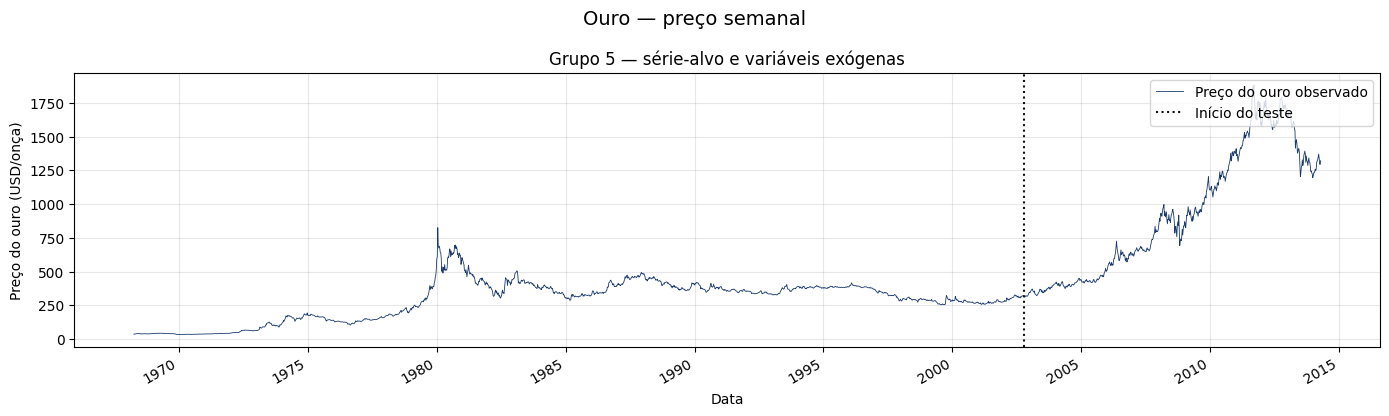

,n,ausentes,media,mediana,minimo,maximo,sinais_outlier_iqr,percentual_outlier_iqr
variavel,,,,,,,,
VALUE,2402,0,446.568,364.55,34.775,1879.5,344,0.143


Decisão: preservar valores extremos plausíveis; não aplicar clipping global.


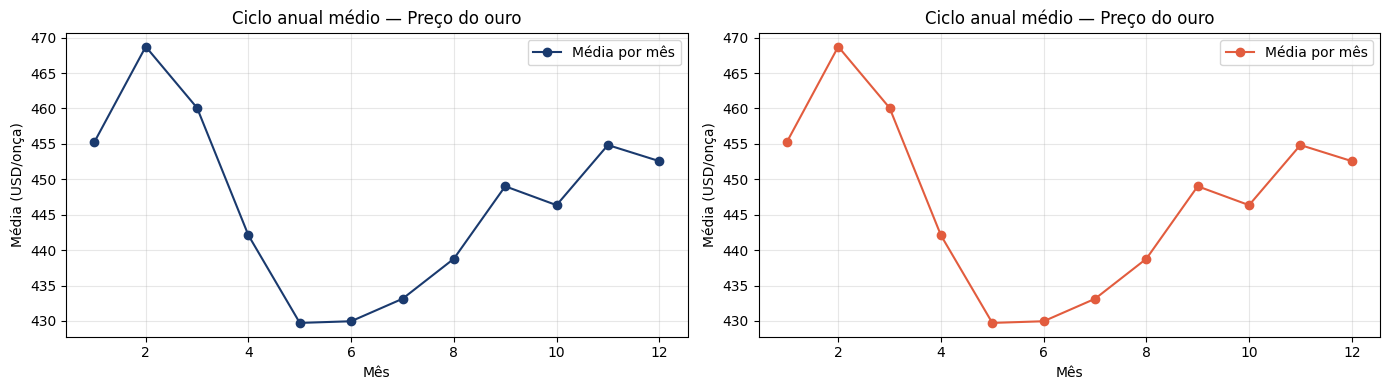

In [6]:
# T03 — análise exploratória visual
colunas_plot = [TARGET_COLUMN] + MODEL_EXOG_COLUMNS
fig, axes = plt.subplots(len(colunas_plot), 1, figsize=(14, 2.2 * len(colunas_plot) + 2),
                         sharex=True, squeeze=False)
axes = axes[:, 0]
axes[0].plot(df.index, df[TARGET_COLUMN], color="#1a3a6e", linewidth=0.6,
             label=f"{ROTULO_ALVO} observado")
axes[0].axvline(INICIO_TESTE, color="#111111", linestyle=":", linewidth=1.5,
                label="Início do teste")
axes[0].set_title("Grupo 5 — série-alvo e variáveis exógenas")
axes[0].set_ylabel(f"{ROTULO_ALVO} ({UNIDADE_ALVO})")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)
for ax, coluna in zip(axes[1:], MODEL_EXOG_COLUMNS):
    ax.plot(df.index, df[coluna], linewidth=0.6, color="#e25c3e", label=coluna)
    ax.axvline(INICIO_TESTE, color="#111111", linestyle=":", linewidth=1.5,
               label="Início do teste")
    ax.set_title(f"Série temporal — {coluna}")
    ax.set_ylabel(coluna)
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Data")
fig.suptitle("Ouro — preço semanal", fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Diagnóstico de outliers pelo critério IQR, sem remoção automática.
resumo = []
for coluna in colunas_plot:
    validos = pd.to_numeric(df[coluna], errors="coerce").dropna()
    q1, q3 = validos.quantile([0.25, 0.75])
    iqr = q3 - q1
    inf, sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    fora = int(((validos < inf) | (validos > sup)).sum())
    resumo.append({"variavel": coluna, "n": int(validos.size),
                   "ausentes": int(df[coluna].isna().sum()),
                   "media": validos.mean(), "mediana": validos.median(),
                   "minimo": validos.min(), "maximo": validos.max(),
                   "sinais_outlier_iqr": fora,
                   "percentual_outlier_iqr": fora / max(1, validos.size)})
display(pd.DataFrame(resumo).set_index("variavel").round(3))
print("Decisão: preservar valores extremos plausíveis; não aplicar clipping global.")

# Perfil médio ao longo do ciclo e ao longo do ano.
fig, (eixo_ciclo, eixo_mes) = plt.subplots(1, 2, figsize=(14, 4))
perfil_ciclo = df[TARGET_COLUMN].groupby(df.index.month).mean()
eixo_ciclo.plot(perfil_ciclo.index, perfil_ciclo.to_numpy(), marker="o",
                color="#1a3a6e", label="Média por mês")
eixo_ciclo.set_title("Ciclo anual médio — Preço do ouro")
eixo_ciclo.set_xlabel("Mês")
eixo_ciclo.set_ylabel(f"Média ({UNIDADE_ALVO})")
eixo_ciclo.legend()
eixo_ciclo.grid(alpha=0.3)

perfil_mes = df[TARGET_COLUMN].groupby(df.index.month).mean()
eixo_mes.plot(perfil_mes.index, perfil_mes.to_numpy(), marker="o",
              color="#e25c3e", label="Média por mês")
eixo_mes.set_title("Ciclo anual médio — Preço do ouro")
eixo_mes.set_xlabel("Mês")
eixo_mes.set_ylabel(f"Média ({UNIDADE_ALVO})")
eixo_mes.legend()
eixo_mes.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 2. Sazonalidade

## T04 — Decomposição STL

Decomposição STL e interpretação gráfica da tendência, incluindo períodos de alta, queda e estabilidade.

STL no treino: 1968-04-05 00:00:00 a 2002-10-04 00:00:00 (1,801 períodos de semana)


Força da sazonalidade (período 52): 0.0000
Força da tendência: 0.9574


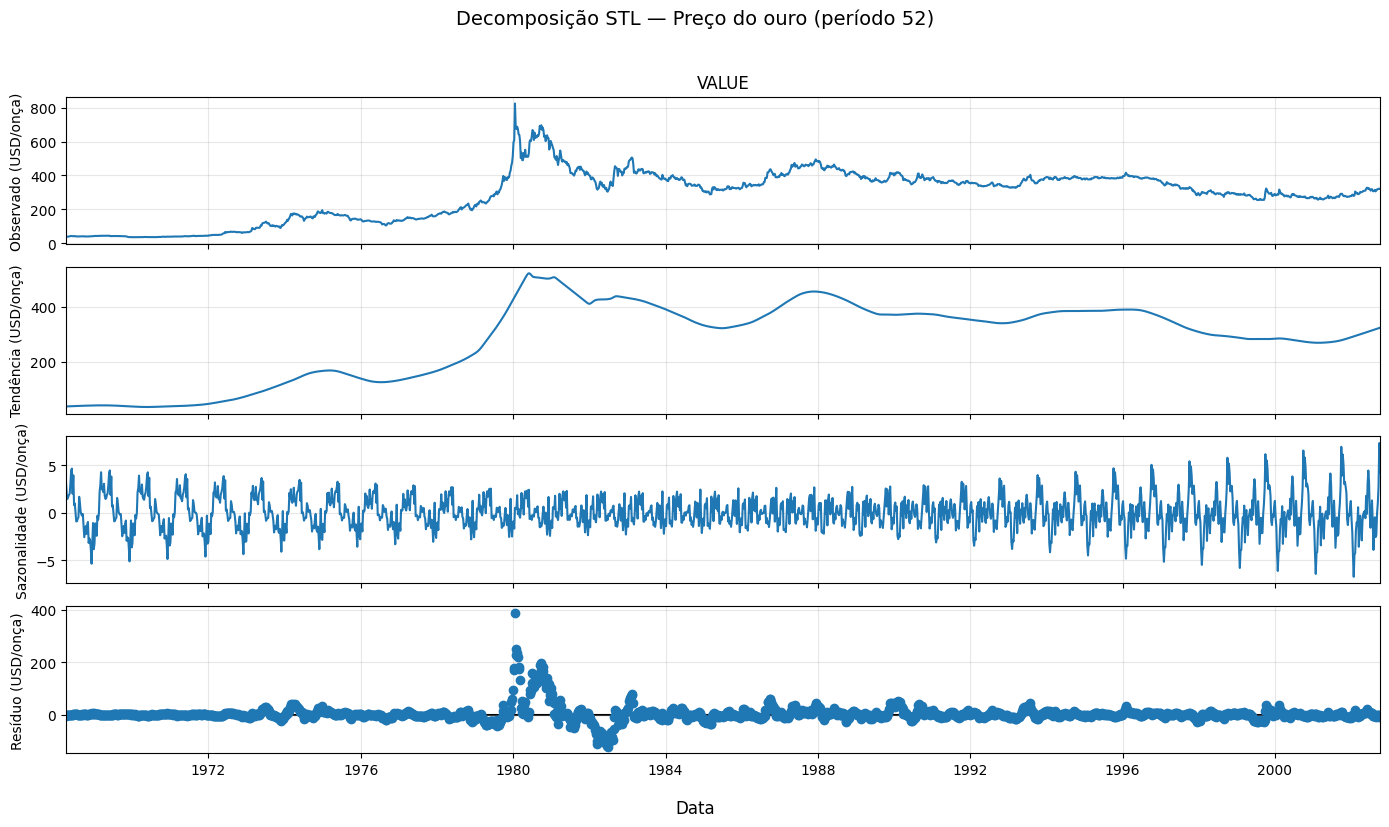

In [7]:
# T04 — decomposição STL no maior trecho contínuo e observado do treino
def maior_trecho_continuo(serie, frequencia):
    """Maior bloco sem lacunas da série observada; a STL não tolera NaN."""
    observada = serie.dropna().sort_index()
    # O passo vem da moda das diferenças: offsets como W-FRI e M não se
    # convertem em Timedelta, mas a diferença observada entre dois períodos sim.
    diferencas = observada.index.to_series().diff()
    passo = diferencas.mode().iloc[0]
    quebra = diferencas.ne(passo).cumsum()
    maior = max(list(observada.groupby(quebra.to_numpy())), key=lambda par: len(par[1]))[1]
    return maior.asfreq(frequencia)

serie_stl = maior_trecho_continuo(df.loc[df.index < INICIO_TESTE, TARGET_COLUMN], FREQUENCY)
if serie_stl.isna().any():
    raise ValueError("O trecho selecionado para a STL ainda contém lacunas.")
if len(serie_stl) < 2 * PERIODO_STL:
    raise ValueError(f"Trecho contínuo curto demais para STL com período {PERIODO_STL}.")
print(f"STL no treino: {serie_stl.index.min()} a {serie_stl.index.max()} "
      f"({len(serie_stl):,} períodos de semana)")

stl_resultado = calcular_forca_sazonalidade(serie_stl, periodo=PERIODO_STL)
decomposicao = stl_resultado["decomposicao"]
print(f"Força da sazonalidade (período {PERIODO_STL}): "
      f"{stl_resultado['forca_sazonalidade']:.4f}")
print(f"Força da tendência: {stl_resultado['forca_tendencia']:.4f}")

fig = decomposicao.plot()
fig.set_size_inches(14, 8)
fig.suptitle(f"Decomposição STL — {ROTULO_ALVO} (período {PERIODO_STL})",
             fontsize=14, y=1.02)
fig.supxlabel("Data")
fig.axes[0].set_ylabel(f"Observado ({UNIDADE_ALVO})")
fig.axes[1].set_ylabel(f"Tendência ({UNIDADE_ALVO})")
fig.axes[2].set_ylabel(f"Sazonalidade ({UNIDADE_ALVO})")
fig.axes[3].set_ylabel(f"Resíduo ({UNIDADE_ALVO})")
for ax in fig.axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## T05 — Força da sazonalidade e resíduos

Cálculo da força da sazonalidade e análise do componente residual.

Média do residual: 2.767856
Desvio-padrão do residual: 29.741741


,lb_stat,lb_pvalue
1,1576.686003,0.0
2,2985.381273,0.0
3,4199.228898,0.0
4,5214.676945,0.0
5,6067.323785,0.0
6,6764.095362,0.0
7,7332.639277,0.0
8,7773.234663,0.0
9,8135.896749,0.0
10,8426.739214,0.0


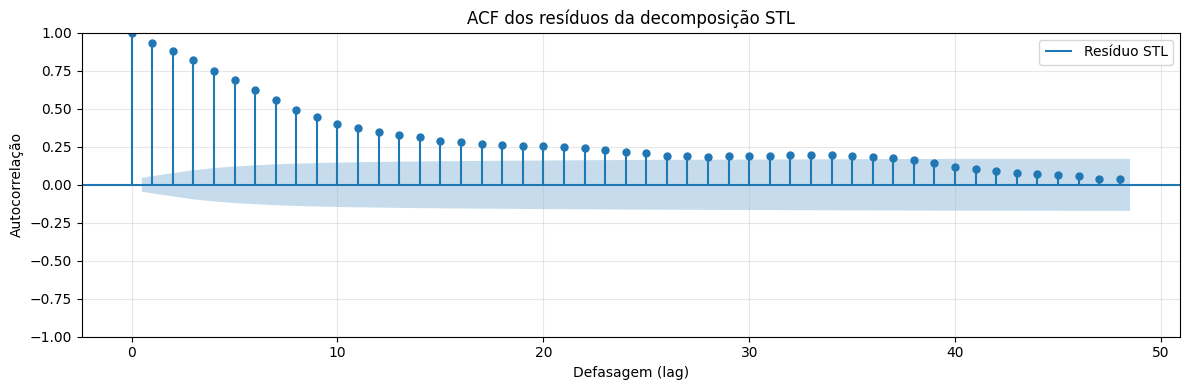

In [8]:
# Análise do componente residual
analise_residuos_stl = analisar_componente_residual(decomposicao, lags=24)
print(f"Média do residual: {analise_residuos_stl['media']:.6f}")
print(f"Desvio-padrão do residual: {analise_residuos_stl['desvio_padrao']:.6f}")
display(analise_residuos_stl["autocorrelacao_residual"])

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(
    analise_residuos_stl["residuo"],
    lags=48,
    ax=ax,
    title="ACF dos resíduos da decomposição STL",
)
ax.set_xlabel("Defasagem (lag)")
ax.set_ylabel("Autocorrelação")
ax.legend(["Resíduo STL"], loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 3. Validação temporal

## T08 — Validação walk-forward

A previsão é **móvel de um passo**: `HORIZON = 1`. A cada semana do bloco de teste o modelo prevê a semana seguinte, a observação realizada é incorporada ao estado, e a previsão avança. As origens cobrem todo o teste, uma por semana.

As exógenas observadas entram defasadas em `EXOG_LAG = 1`: o valor usado para prever `t` é o de `t − 1`, que já estava disponível. As variáveis de calendário entram sem defasagem, porque são determinísticas e conhecidas com antecedência. A sazonalidade nenhuma não entra como variável: quando existe, é modelada pelo próprio SARIMAX.

A máscara de elegibilidade reproduz os lags e janelas móveis usados na Random Forest e na MLP, pela função compartilhada `features_temporais.preparar_features_base`. Ela não alimenta o SARIMAX — serve para que os três modelos sejam avaliados exatamente nos mesmos instantes, o que é condição para comparar MAE entre eles.

O corte treino/teste vem dos metadados da base tratada, definido sobre a grade completa antes de qualquer defasagem, e a divisão aqui é feita por data e não por posição. A célula reporta o split declarado e o efetivo, que podem divergir quando as lacunas se concentram de um lado do corte.


In [9]:
# T08 — exógenas causais, máscara de elegibilidade e divisão temporal
# A máscara vem de features_temporais.preparar_features_base, o MESMO módulo que
# gera as features da Random Forest e da MLP. Usar a função compartilhada, em vez
# de reimplementá-la, garante que os três modelos sejam avaliados exatamente nos
# mesmos períodos — é isso que torna o MAE comparável entre eles.
COMPONENTES_CALENDARIO = {
    "hora": (df.index.hour, 24),
    "dia_semana": (df.index.dayofweek, 7),
    "dia_ano": (df.index.dayofyear, 365.25),
}

features = pd.DataFrame(index=df.index)
# (a) exógenas observadas: só existem depois do fato, entram defasadas.
for coluna in EXOG_COLUMNS:
    features[f"{coluna}_lag{EXOG_LAG}"] = df[coluna].shift(EXOG_LAG)
# (b) calendário: determinístico e conhecido com antecedência, entra sem defasagem.
for item in CALENDARIO:
    valores, periodo = COMPONENTES_CALENDARIO[item]
    features[f"{item}_sin"] = np.sin(2 * np.pi * valores / periodo)
    features[f"{item}_cos"] = np.cos(2 * np.pi * valores / periodo)
# (c) indicadores de calendário conhecidos antecipadamente (feriado, por exemplo).
for coluna, referencia in INDICADORES_CONHECIDOS.items():
    features[f"{coluna}_indicador"] = (
        df[coluna].ne(referencia).astype(float).where(df[coluna].notna())
    )

elegibilidade = ft.preparar_features_base(
    df, BASE_NAME, TARGET_COLUMN, FREQUENCY, remover_incompletos=True
).index

model_data = pd.concat([df[TARGET_COLUMN].rename("target"), features], axis=1).dropna()
model_data = model_data.loc[model_data.index.intersection(elegibilidade)]

train = model_data.loc[model_data.index < INICIO_TESTE]
test = model_data.loc[model_data.index >= INICIO_TESTE]
if train.empty or test.empty or train.index.max() >= test.index.min():
    raise ValueError("Divisão temporal inválida.")
y_train, y_test = train["target"], test["target"]
X_train, X_test = train.drop(columns="target"), test.drop(columns="target")

if len(y_train) <= JANELA_SELECAO + PASSOS_VALIDACAO:
    raise ValueError(
        f"Treino com {len(y_train):,} períodos é curto demais para "
        f"JANELA_SELECAO ({JANELA_SELECAO}) + PASSOS_VALIDACAO ({PASSOS_VALIDACAO})."
    )

# O split declarado vale para a GRADE completa. Depois da máscara de
# elegibilidade, a proporção efetivamente modelada pode ser outra, porque as
# lacunas não se distribuem igualmente entre treino e teste. As duas são
# reportadas: a declarada é o contrato do grupo, a efetiva é o que o modelo viu.
print(f"Split declarado na grade: {TRAIN_RATIO:.0%} / {1 - TRAIN_RATIO:.0%}")
print(f"Treino: {len(train):,} ({len(train) / len(model_data):.1%}) | "
      f"teste: {len(test):,} ({len(test) / len(model_data):.1%})")
if abs(len(train) / len(model_data) - TRAIN_RATIO) > 0.02:
    print(f"ATENÇÃO: a proporção efetiva difere da declarada em mais de 2 pontos. "
          f"As lacunas descartadas pela máscara se concentram em um dos lados do "
          f"corte. Relate o split efetivo, e não o declarado, ao comparar modelos.")
print(f"Corte comum: {FIM_TREINO} -> {INICIO_TESTE}")
print(f"Horizonte: {HORIZON} período | defasagem das exógenas: {EXOG_LAG} período")
print(f"Exógenas ({X_train.shape[1]}): {list(X_train.columns)}")
print(f"Origens de previsão no teste: {len(y_test):,}")

# ---- continuidade da série efetivamente entregue ao SARIMAX ----
# O SARIMAX recebe arrays e trata as observações como consecutivas. Quando a
# máscara descarta muitos períodos, os termos AR/MA passam a ligar instantes que
# não são vizinhos no tempo. Isto não é um detalhe cosmético: é a premissa do
# modelo. O diagnóstico abaixo torna o tamanho do problema visível.
descartados = len(df) - len(model_data)
saltos = model_data.index.to_series().diff()
passo_esperado = saltos.mode().iloc[0]
quebras = int(saltos.ne(passo_esperado).sum() - 1)
maior_bloco = int(saltos.ne(passo_esperado).cumsum().value_counts().iloc[0])
print(f"\nPeríodos descartados pela máscara de elegibilidade: {descartados:,} "
      f"({descartados / len(df):.1%} da grade)")
print(f"Descontinuidades na série modelada: {quebras:,} | "
      f"maior bloco contíguo: {maior_bloco:,} períodos")
if descartados / len(df) > 0.05:
    print("ATENÇÃO: mais de 5% da grade foi descartada. Os termos AR/MA e a "
          "diferenciação sazonal passam a operar sobre observações que não são "
          "consecutivas no tempo, o que viola a premissa do SARIMAX. A Random "
          "Forest e a MLP não sofrem com isso, porque leem cada linha de forma "
          "independente. Leia o MAE deste notebook com essa ressalva.")


Split declarado na grade: 75% / 25%
Treino: 1,775 (74.7%) | teste: 601 (25.3%)
Corte comum: 2002-10-04 00:00:00 -> 2002-10-11 00:00:00
Horizonte: 1 período | defasagem das exógenas: 1 período
Exógenas (2): ['dia_ano_sin', 'dia_ano_cos']
Origens de previsão no teste: 601

Períodos descartados pela máscara de elegibilidade: 26 (1.1% da grade)
Descontinuidades na série modelada: 0 | maior bloco contíguo: 2,376 períodos


# 4. Modelagem SARIMAX

## T10 — SARIMAX

Seleção de `p`, `d`, `q`, `P`, `D` e `Q` por critério de informação. O grid é o **produto cartesiano completo** dos intervalos da configuração — nenhum parâmetro é fixado de fora —, com 17 combinações, e o vencedor é o de menor `INFORMATION_CRITERION`.

**Sazonalidade.** Nenhuma: o grid é de ARIMA puro, com `P = D = Q = 0` e `m = 1`.

**Janela de ajuste.** O grid usa 1.040 semanas, cerca de vinte anos do fim do treino, e não a série inteira. O custo do filtro de Kalman cresce com o número de observações, de modo que a janela reduz o tempo por ajuste sem alterar a ordenação relativa dos candidatos, que é o que o critério de informação precisa produzir. A janela termina **antes** do bloco de validação, que por isso permanece fora da amostra.

**Truncamento do otimizador.** A triagem usa `maxiter = 50` porque o grid completo com limite alto não cabe no orçamento. Um ajuste truncado tem critério de informação pior do que teria no ótimo, então a ordenação da triagem é indicativa: os `REFINO_TOP_K` melhores são reajustados com `maxiter = 200` antes de a decisão ser congelada. O grid barato ordena, o reajuste caro confirma — e a célula avisa quando o refino muda o vencedor.

**Orçamento.** Os tempos de ajuste desta base não foram medidos previamente. A célula cronometra um ajuste piloto pesado, projeta o custo do grid inteiro e **aborta antes de começar** se a projeção passar de metade de `ORCAMENTO_MAX_HORAS`. Se isso acontecer, reduza `JANELA_SELECAO` ou `MAXITER`.


Janela do grid: 1981-11-06 00:00:00 a 2001-10-05 00:00:00 (1,040 obs)
Bloco de validação: 2001-10-12 00:00:00 a 2002-10-04 00:00:00 (52 obs)
Combinações no grid: 17 | m = 0 | critério: BIC


Ajuste piloto (2, 1, 2)x(0, 0, 0, 0): 0.9s (ok)
Orçamento previsto da triagem: 0 min (17 ajustes em 4 processos)


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    8.4s


[Parallel(n_jobs=4)]: Done  14 out of  17 | elapsed:    9.5s remaining:    2.0s


...

Refinando os 5 melhores com maxiter=200: ~0 min previstos


[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    0.1s remaining:    0.2s


[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    0.3s finished


,order,seasonal_order,maxiter,AIC,BIC,AICc,convergiu,iteracoes,segundos,falha
0,"(0, 1, 0)","(0, 0, 0, 0)",200,-1066.356,-1046.576,-1066.318,True,6,0.2,
1,"(0, 1, 1)","(0, 0, 0, 0)",200,-1069.288,-1044.568,-1069.230,True,9,0.3,
2,"(1, 1, 0)","(0, 0, 0, 0)",200,-1068.890,-1044.165,-1068.832,True,3,0.1,
3,"(1, 0, 0)","(0, 0, 0, 0)",200,-1068.449,-1043.719,-1068.391,True,4,0.2,
4,"(2, 0, 0)","(0, 0, 0, 0)",200,-1072.657,-1042.987,-1072.576,True,9,0.3,


O refinamento confirmou o vencedor da triagem.
Hiperparâmetros congelados por BIC: order=(0, 1, 0) | seasonal_order=(0, 0, 0, 0)
  melhor da triagem por AIC : order=(2, 1, 2) seasonal_order=(0, 0, 0, 0) (AIC = -1073.3)
  melhor da triagem por BIC : order=(0, 1, 0) seasonal_order=(0, 0, 0, 0) (BIC = -1046.6)
  melhor da triagem por AICc: order=(2, 1, 2) seasonal_order=(0, 0, 0, 0) (AICc = -1073.1)


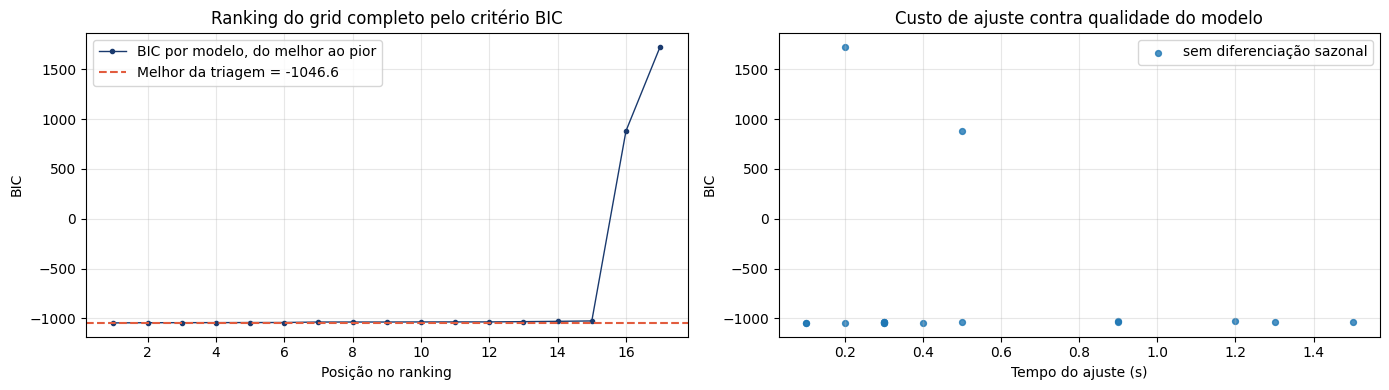

Tempo total da T10: 0.2 min (0% do teto)


In [10]:
# T10 — grid completo de (p, d, q) x (P, D, Q, m) por critério de informação
tempo_t10 = time.perf_counter()

# A janela do grid termina onde começa o bloco de validação.
y_grid = y_train.iloc[-(JANELA_SELECAO + PASSOS_VALIDACAO):-PASSOS_VALIDACAO]
X_grid = X_train.loc[y_grid.index]
y_validacao = y_train.iloc[-PASSOS_VALIDACAO:]
X_validacao = X_train.loc[y_validacao.index]
print(f"Janela do grid: {y_grid.index[0]} a {y_grid.index[-1]} ({len(y_grid):,} obs)")
print(f"Bloco de validação: {y_validacao.index[0]} a {y_validacao.index[-1]} "
      f"({len(y_validacao):,} obs)")

escala_y_grid, escala_x_grid = StandardScaler(), StandardScaler()
y_grid_sc = escala_y_grid.fit_transform(y_grid.to_numpy().reshape(-1, 1)).ravel()
X_grid_sc = escala_x_grid.fit_transform(X_grid.to_numpy())

# Produto cartesiano completo, sem o modelo nulo (sem termos e sem diferenciação).
combos = [
    c
    for c in itertools.product(P_RANGE, D_RANGE, Q_RANGE, PS_RANGE, DS_RANGE, QS_RANGE)
    if not (c[0] + c[2] + c[3] + c[5] == 0 and c[1] + c[4] == 0)
]
print(f"Combinações no grid: {len(combos)} | m = {M_MODELO} | "
      f"critério: {INFORMATION_CRITERION.upper()}")

COLUNA_CRITERIO = {"aic": "AIC", "bic": "BIC", "aicc": "AICc"}[INFORMATION_CRITERION]


def _ajustar(combo, maxiter):
    p, d, q, P, D, Q = combo
    registro = {"order": (p, d, q), "seasonal_order": (P, D, Q, M_MODELO),
                "maxiter": maxiter}
    inicio = time.perf_counter()
    try:
        modelo = SARIMAX(
            y_grid_sc, exog=X_grid_sc,
            order=(p, d, q), seasonal_order=(P, D, Q, M_MODELO), trend=TREND,
            enforce_stationarity=ENFORCE_STATIONARITY,
            enforce_invertibility=ENFORCE_INVERTIBILITY,
            concentrate_scale=CONCENTRATE_SCALE,
        ).fit(disp=False, maxiter=maxiter)
    except Exception as exc:
        registro.update({"AIC": np.nan, "BIC": np.nan, "AICc": np.nan,
                         "convergiu": False, "iteracoes": np.nan,
                         "segundos": round(time.perf_counter() - inicio, 1),
                         "falha": type(exc).__name__})
        return registro
    k = modelo.df_model
    registro.update({
        "AIC": modelo.aic,
        "BIC": modelo.bic,
        "AICc": modelo.aic + (2 * k * (k + 1)) / max(modelo.nobs - k - 1, 1),
        "convergiu": bool(modelo.mle_retvals.get("converged", False)),
        "iteracoes": modelo.mle_retvals.get("iterations", np.nan),
        "segundos": round(time.perf_counter() - inicio, 1),
        "falha": "",
    })
    return registro


# ---------- 1. triagem: grid completo com maxiter curto ----------
# Ajuste piloto de um modelo pesado (com diferenciação sazonal), que é o que
# domina o custo; usar um combo leve subestimaria o orçamento.
combo_piloto = (2, 1, 2, 1, 1, 1) if (2, 1, 2, 1, 1, 1) in combos else combos[-1]
inicio_piloto = time.perf_counter()
piloto = _ajustar(combo_piloto, MAXITER)
segundos_piloto = time.perf_counter() - inicio_piloto
# Modelos sem diferenciação sazonal custam cerca de um quarto do piloto.
fracao_pesada = sum(1 for c in combos if c[4] == 1) / len(combos)
segundos_medios = segundos_piloto * (fracao_pesada + 0.25 * (1 - fracao_pesada))
horas_previstas = segundos_medios * len(combos) / max(N_JOBS_GRID, 1) / 3600
print(f"Ajuste piloto {piloto['order']}x{piloto['seasonal_order']}: "
      f"{segundos_piloto:.1f}s ({'ok' if not piloto['falha'] else piloto['falha']})")
print(f"Orçamento previsto da triagem: {horas_previstas * 60:.0f} min "
      f"({len(combos)} ajustes em {N_JOBS_GRID} processos)")
if horas_previstas > ORCAMENTO_MAX_HORAS / 2:
    raise RuntimeError(
        f"A triagem sozinha consumiria {horas_previstas:.1f} h, mais da metade do "
        f"teto de {ORCAMENTO_MAX_HORAS} h. Reduza JANELA_SELECAO ou MAXITER."
    )

triagem = Parallel(n_jobs=N_JOBS_GRID, verbose=5)(
    delayed(_ajustar)(combo, MAXITER) for combo in combos
)
df_grid = (
    pd.DataFrame(triagem)
    .dropna(subset=[COLUNA_CRITERIO])
    .sort_values(COLUNA_CRITERIO)
    .reset_index(drop=True)
)
print(f"Modelos ajustados: {len(df_grid)} de {len(combos)} | "
      f"convergidos em até {MAXITER} iterações: {int(df_grid['convergiu'].sum())}")
display(df_grid.head(10).round(3))

ORDER_TRIAGEM = tuple(df_grid.loc[0, "order"])
SEASONAL_ORDER_TRIAGEM = tuple(df_grid.loc[0, "seasonal_order"])

# ---------- 2. refinamento dos melhores com maxiter longo ----------
if REFINO_TOP_K > 0:
    a_refinar = [
        (linha["order"][0], linha["order"][1], linha["order"][2],
         linha["seasonal_order"][0], linha["seasonal_order"][1],
         linha["seasonal_order"][2])
        for _, linha in df_grid.head(REFINO_TOP_K).iterrows()
    ]
    horas_refino = (
        df_grid.head(REFINO_TOP_K)["segundos"].sum()
        * (MAXITER_REFINO / MAXITER) / max(N_JOBS_GRID, 1) / 3600
    )
    print(f"Refinando os {len(a_refinar)} melhores com maxiter={MAXITER_REFINO}: "
          f"~{horas_refino * 60:.0f} min previstos")
    refino = Parallel(n_jobs=min(N_JOBS_GRID, len(a_refinar)), verbose=5)(
        delayed(_ajustar)(combo, MAXITER_REFINO) for combo in a_refinar
    )
    df_refino = (
        pd.DataFrame(refino)
        .dropna(subset=[COLUNA_CRITERIO])
        .sort_values(COLUNA_CRITERIO)
        .reset_index(drop=True)
    )
    display(df_refino.round(3))
    ORDER = tuple(df_refino.loc[0, "order"])
    SEASONAL_ORDER = tuple(df_refino.loc[0, "seasonal_order"])
    if (ORDER, SEASONAL_ORDER) != (ORDER_TRIAGEM, SEASONAL_ORDER_TRIAGEM):
        print(f"O refinamento MUDOU o vencedor: a triagem apontava "
              f"{ORDER_TRIAGEM}{SEASONAL_ORDER_TRIAGEM} e o reajuste longo aponta "
              f"{ORDER}{SEASONAL_ORDER}. A ordenação com maxiter={MAXITER} "
              f"estava contaminada pelo truncamento do otimizador.")
    else:
        print("O refinamento confirmou o vencedor da triagem.")
else:
    ORDER, SEASONAL_ORDER = ORDER_TRIAGEM, SEASONAL_ORDER_TRIAGEM

print(f"Hiperparâmetros congelados por {COLUNA_CRITERIO}: "
      f"order={ORDER} | seasonal_order={SEASONAL_ORDER}")

# Se AIC, BIC e AICc apontam modelos diferentes, a escolha depende do critério
# e não dos dados. Isso precisa ficar visível, não escondido no vencedor.
for criterio in ("AIC", "BIC", "AICc"):
    linha = df_grid.sort_values(criterio).iloc[0]
    print(f"  melhor da triagem por {criterio:4s}: order={tuple(linha['order'])} "
          f"seasonal_order={tuple(linha['seasonal_order'])} "
          f"({criterio} = {linha[criterio]:.1f})")

fig, (eixo_rank, eixo_custo) = plt.subplots(1, 2, figsize=(14, 4))
valores = df_grid[COLUNA_CRITERIO].to_numpy()
eixo_rank.plot(range(1, len(valores) + 1), valores, marker="o", markersize=3,
               linewidth=1.0, color="#1a3a6e",
               label=f"{COLUNA_CRITERIO} por modelo, do melhor ao pior")
eixo_rank.axhline(valores[0], color="#e25c3e", linestyle="--",
                  label=f"Melhor da triagem = {valores[0]:.1f}")
eixo_rank.set_title(f"Ranking do grid completo pelo critério {COLUNA_CRITERIO}")
eixo_rank.set_xlabel("Posição no ranking")
eixo_rank.set_ylabel(COLUNA_CRITERIO)
eixo_rank.legend()
eixo_rank.grid(alpha=0.3)

custo = df_grid.assign(
    sazonal=np.where([s[1] == 1 for s in df_grid["seasonal_order"]],
                     "com diferenciação sazonal", "sem diferenciação sazonal")
)
for rotulo, grupo in custo.groupby("sazonal"):
    eixo_custo.scatter(grupo["segundos"], grupo[COLUNA_CRITERIO], s=18,
                       alpha=0.8, label=rotulo)
eixo_custo.set_title("Custo de ajuste contra qualidade do modelo")
eixo_custo.set_xlabel("Tempo do ajuste (s)")
eixo_custo.set_ylabel(COLUNA_CRITERIO)
eixo_custo.legend()
eixo_custo.grid(alpha=0.3)
plt.tight_layout()
plt.show()

tempo_t10 = time.perf_counter() - tempo_t10
print(f"Tempo total da T10: {tempo_t10 / 60:.1f} min "
      f"({tempo_t10 / 3600 / ORCAMENTO_MAX_HORAS:.0%} do teto)")


### Conferência do modelo escolhido no bloco de validação

O critério de informação mede a qualidade do ajuste dentro da amostra, com penalização pelo número de parâmetros. Ele **não** mede erro de previsão de um passo à frente, que é a tarefa avaliada na T16.

Esta célula não escolhe nada: os hiperparâmetros já estão congelados. Ela ajusta o vencedor no histórico anterior ao bloco de validação e percorre 52 semanas seguintes em previsão móvel de um passo, informando qual MAE esperar antes de gastar o orçamento da T16.

O ajuste usa **a mesma janela de estimação** que a T16 usará em cada reajuste — o histórico completo, já que `JANELA_REFIT` é `None` nesta base. Isso tem duas consequências desejáveis: o MAE de validação fica comparável com o MAE de teste, porque os dois vêm de modelos estimados sobre a mesma quantidade de histórico; e o tempo cronometrado aqui vira uma régua exata do custo de um reajuste da T16, e não uma extrapolação.

O procedimento usa `append(..., refit=False)`, que incorpora as observações já realizadas ao filtro de Kalman sem reestimar os parâmetros. As previsões obtidas assim são idênticas, valor a valor, às de um laço que prevê um passo e reencaixa a observação, mas custam uma passagem do filtro em vez de centenas.

A célula também imprime `k_states` e o tamanho projetado das matrizes de covariância de estado. Essas matrizes têm forma `(k_states, k_states, nobs)` e foram o que esgotou a memória da máquina na primeira execução do grupo 4. Ao final, os objetos de resultados são descartados com `del` e `gc.collect()`.


Ajuste da conferência: 1,723 obs (1968-10-04 00:00:00 a 2001-10-05 00:00:00)
Janela de reajuste: histórico completo | k_states = 2
Uma matriz de covariância de estado: 0.00 GB


Ajuste concluído em 0.0 min | convergiu: True
MAE de validação de SARIMAX(0, 1, 0)(0, 0, 0, 0): 4.2143 USD/onça
RMSE de validação: 5.7312 USD/onça | viés médio: +0.4324 USD/onça


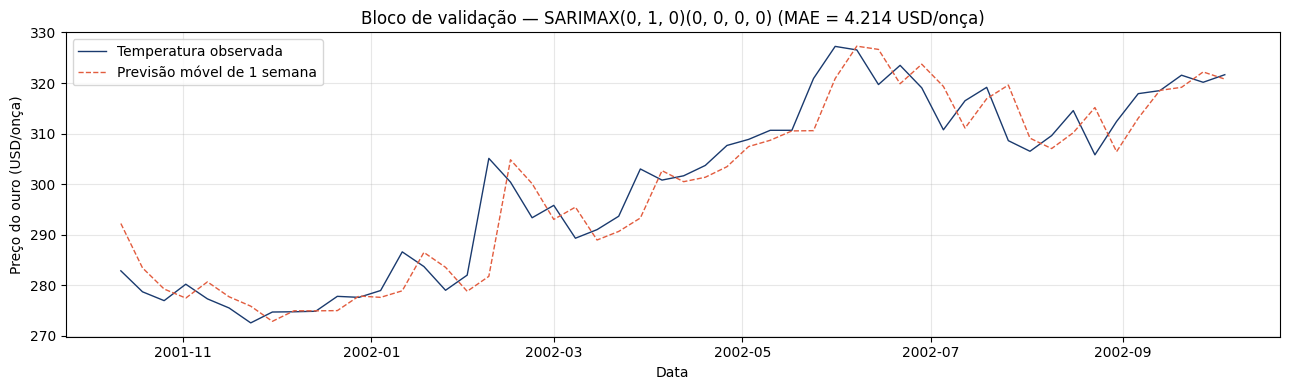

Tempo total da conferência: 0.0 min
Gasto acumulado: 0.00 h de 5.0 h | restam 4.25 h úteis
A T16 quer 12 reajustes e o orçamento comporta 51317; ela usará o menor dos dois.


In [11]:
# T10b — conferência do modelo congelado no bloco de validação
tempo_t10b = time.perf_counter()

# Mesma janela dos reajustes da T16, para que o MAE e o tempo sejam comparáveis.
y_ajuste = y_train.loc[y_train.index < y_validacao.index[0]]
if JANELA_REFIT is not None:
    y_ajuste = y_ajuste.iloc[-JANELA_REFIT:]
X_ajuste = X_train.loc[y_ajuste.index]

escala_y_val, escala_x_val = StandardScaler(), StandardScaler()
y_ajuste_sc = escala_y_val.fit_transform(y_ajuste.to_numpy().reshape(-1, 1)).ravel()
X_ajuste_sc = escala_x_val.fit_transform(X_ajuste.to_numpy())
X_validacao_sc = escala_x_val.transform(X_validacao.to_numpy())
y_validacao_sc = escala_y_val.transform(y_validacao.to_numpy().reshape(-1, 1)).ravel()

# Projeção de memória antes de ajustar: k_states depende de (p, d, q) e de
# (P, D, Q, m), e as covariâncias de estado têm forma (k_states, k_states, nobs).
modelo_validacao = SARIMAX(
    y_ajuste_sc, exog=X_ajuste_sc, order=ORDER, seasonal_order=SEASONAL_ORDER,
    trend=TREND,
    enforce_stationarity=ENFORCE_STATIONARITY,
    enforce_invertibility=ENFORCE_INVERTIBILITY,
    concentrate_scale=CONCENTRATE_SCALE,
)
K_STATES = modelo_validacao.k_states
gb_por_matriz = K_STATES ** 2 * (len(y_ajuste_sc) + PASSOS_VALIDACAO) * 8 / 1e9
print(f"Ajuste da conferência: {len(y_ajuste):,} obs "
      f"({y_ajuste.index[0]} a {y_ajuste.index[-1]})")
print(f"Janela de reajuste: "
      f"{'histórico completo' if JANELA_REFIT is None else f'{JANELA_REFIT} sem'} | "
      f"k_states = {K_STATES}")
print(f"Uma matriz de covariância de estado: {gb_por_matriz:.2f} GB")

inicio_ajuste = time.perf_counter()
ajuste_validacao = modelo_validacao.fit(disp=False, maxiter=MAXITER)
SEGUNDOS_POR_REFIT = time.perf_counter() - inicio_ajuste
print(f"Ajuste concluído em {SEGUNDOS_POR_REFIT / 60:.1f} min | "
      f"convergiu: {ajuste_validacao.mle_retvals.get('converged', False)}")

n_ajuste = len(y_ajuste_sc)
estado_validacao = ajuste_validacao.append(
    y_validacao_sc, exog=X_validacao_sc, refit=False
)
previsao_sc = np.asarray(
    estado_validacao.get_prediction(
        start=n_ajuste, end=n_ajuste + len(y_validacao_sc) - 1, dynamic=False
    ).predicted_mean
)
previsao_validacao = escala_y_val.inverse_transform(
    previsao_sc.reshape(-1, 1)
).ravel()

# Os objetos de resultados guardam as covariâncias de estado dimensionadas
# acima. A T16 vai alocar as suas, então estes precisam sair da memória agora.
del estado_validacao, ajuste_validacao, modelo_validacao
gc.collect()

df_validacao = pd.DataFrame({
    "data": y_validacao.index,
    "real": y_validacao.to_numpy(),
    "previsto": previsao_validacao,
})
df_validacao["residuo"] = df_validacao["real"] - df_validacao["previsto"]
MAE_VALIDACAO = df_validacao["residuo"].abs().mean()
RMSE_VALIDACAO = np.sqrt(np.mean(np.square(df_validacao["residuo"])))
print(f"MAE de validação de SARIMAX{ORDER}{SEASONAL_ORDER}: {MAE_VALIDACAO:.4f} USD/onça")
print(f"RMSE de validação: {RMSE_VALIDACAO:.4f} USD/onça | "
      f"viés médio: {df_validacao['residuo'].mean():+.4f} USD/onça")

fig, eixo = plt.subplots(figsize=(13, 4))
eixo.plot(df_validacao["data"], df_validacao["real"], color="#1a3a6e",
          linewidth=1.0, label="Temperatura observada")
eixo.plot(df_validacao["data"], df_validacao["previsto"], color="#e25c3e",
          linewidth=1.0, linestyle="--", label="Previsão móvel de 1 semana")
eixo.set_title(f"Bloco de validação — SARIMAX{ORDER}{SEASONAL_ORDER} "
               f"(MAE = {MAE_VALIDACAO:.3f} USD/onça)")
eixo.set_xlabel("Data")
eixo.set_ylabel("Preço do ouro (USD/onça)")
eixo.legend()
eixo.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Projeção do custo da T16. Com JANELA_REFIT os reajustes do teste têm
# exatamente o mesmo tamanho do ajuste acima, então isto não é extrapolação.
tempo_t10b = time.perf_counter() - tempo_t10b
n_refits_alvo = int(np.ceil(len(y_test) / REFIT_ALVO_PASSOS))
tempo_disponivel = (
    ORCAMENTO_MAX_HORAS * 3600 * (1 - MARGEM_ORCAMENTO) - tempo_t10 - tempo_t10b
)
n_refits_possiveis = int(tempo_disponivel // SEGUNDOS_POR_REFIT)
print(f"Tempo total da conferência: {tempo_t10b / 60:.1f} min")
print(f"Gasto acumulado: {(tempo_t10 + tempo_t10b) / 3600:.2f} h de "
      f"{ORCAMENTO_MAX_HORAS} h | restam {tempo_disponivel / 3600:.2f} h úteis")
print(f"A T16 quer {n_refits_alvo} reajustes e o orçamento comporta "
      f"{n_refits_possiveis}; ela usará o menor dos dois.")


# 5. Avaliação

## T16 — Comparação por MAE

A avaliação percorre **todas as semanas** do bloco de teste em previsão móvel de um passo: para cada instante `t`, o modelo prevê `t` usando exógenas de `t − 1` e todas as observações até `t − 1`.

O teste é dividido em blocos. No início de cada bloco os parâmetros são reestimados sobre **todo o histórico disponível até ali**, já que `JANELA_REFIT` é `None` nesta base; dentro do bloco, as observações realizadas entram no filtro de Kalman com `append(..., refit=False)`, que atualiza o estado sem reestimar nada. A distinção importa: a janela limita o histórico usado para **estimar os parâmetros**, e não a informação usada para **prever** — toda observação realizada até o passo anterior continua entrando no estado do filtro.

Como não há janela, o custo de cada reajuste cresce ao longo do teste. A série é curta o bastante para isso ser aceitável; se deixar de ser, basta definir `JANELA_REFIT`.

Reestimar a cada passo seriam milhares de ajustes, o que é inviável; não reestimar nunca ignoraria qualquer mudança ao longo do teste. O número de reajustes é, por isso, **derivado do orçamento**: a célula parte do alvo de um reajuste a cada 52 semanas e o reduz se o tempo restante até `ORCAMENTO_MAX_HORAS` não comportar todos, usando o custo já cronometrado na conferência da seção anterior. É uma decisão de custo, declarada e visível, e não uma escolha estatística.

Ao fim de cada bloco os objetos de resultados são descartados com `del` e `gc.collect()`, para que a memória não se acumule de um bloco para o seguinte.

O MAE está em USD/onça e usa apenas previsões fora da amostra. Como o horizonte é de um passo, o MAE por passo perde sentido; no lugar dele a célula reporta o MAE ao longo do tempo e por posição no ciclo, que mostram em que condições o modelo erra mais.


Orçamento: 5.0 h | já gastos 0.00 h | restam 4.25 h (com margem de 15%)
Custo de um reajuste: 0.0 min -> cabem 51317 | alvo era 12
Semanas no teste: 601 | blocos: 12 (51 sem cada)
Janela de estimação por bloco: histórico completo | k_states = 2


Bloco 1/12 | 2002-10-11 00:00:00 a 2003-09-26 00:00:00 | estimado em 1,775 obs | MAE 6.2027 USD/onça | ajuste 0.0 min


Bloco 2/12 | 2003-10-03 00:00:00 a 2004-09-17 00:00:00 | estimado em 1,826 obs | MAE 6.5692 USD/onça | ajuste 0.0 min


Bloco 3/12 | 2004-09-24 00:00:00 a 2005-09-09 00:00:00 | estimado em 1,877 obs | MAE 5.3844 USD/onça | ajuste 0.0 min


C:\Users\gabrieloliveira-ieg\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

Bloco 10/12 | 2011-07-29 00:00:00 a 2012-07-13 00:00:00 | estimado em 2,234 obs | MAE 41.9776 USD/onça | ajuste 0.0 min


Bloco 11/12 | 2012-07-20 00:00:00 a 2013-07-05 00:00:00 | estimado em 2,285 obs | MAE 27.7979 USD/onça | ajuste 0.0 min


Bloco 12/12 | 2013-07-12 00:00:00 a 2014-04-11 00:00:00 | estimado em 2,336 obs | MAE 24.0558 USD/onça | ajuste 0.0 min

Previsões de uma semana: 601 | reajustes: 12
Tempo da avaliação: 0.1 min
Tempo total do pipeline: 0.01 h de um teto de 5.0 h


,base,modelo,horizonte_passos,MAE,RMSE,ME_vies,MaxAE,n_previsoes,refits,passos_por_refit,janela_refit_passos,MAE_validacao,tempo_t10_min,tempo_avaliacao_min
0,ouro,"SARIMAX (0, 1, 0)(0, 0, 0, 0)",1,19.5104,27.9831,1.2801,134.1041,601,12,51,1775,4.2143,0.2048,0.1101


MAE de validação: 4.2143 USD/onça | MAE de teste: 19.5104 USD/onça. Os dois vêm de modelos estimados sobre a mesma janela, então a diferença entre eles mede mudança de período, e não diferença de quantidade de histórico.
Cobertura do IC 95%: 75.0% (esperado cerca de 95%)


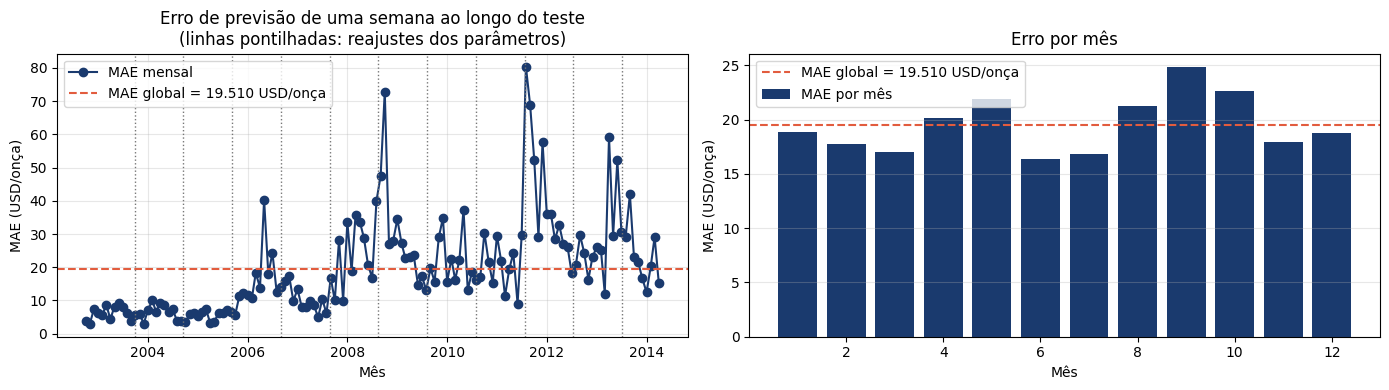

In [12]:
# T16 — previsão móvel de uma semana no teste, com reajuste em janela deslizante
tempo_avaliacao = time.perf_counter()

# ---------- número de reajustes derivado do orçamento restante ----------
tempo_gasto = tempo_t10 + tempo_t10b
tempo_restante = ORCAMENTO_MAX_HORAS * 3600 * (1 - MARGEM_ORCAMENTO) - tempo_gasto
if tempo_restante <= SEGUNDOS_POR_REFIT:
    raise RuntimeError(
        f"Restam {tempo_restante / 60:.0f} min do orçamento e um único reajuste custa "
        f"{SEGUNDOS_POR_REFIT / 60:.0f} min. Aumente ORCAMENTO_MAX_HORAS ou reduza "
        f"JANELA_REFIT e rode a T10b de novo."
    )
n_refits_possiveis = int(tempo_restante // SEGUNDOS_POR_REFIT)
n_refits_alvo = int(np.ceil(len(y_test) / REFIT_ALVO_PASSOS))
N_REFITS = max(1, min(n_refits_alvo, n_refits_possiveis))
REFIT_EVERY_PASSOS = int(np.ceil(len(y_test) / N_REFITS))

print(f"Orçamento: {ORCAMENTO_MAX_HORAS} h | já gastos {tempo_gasto / 3600:.2f} h | "
      f"restam {tempo_restante / 3600:.2f} h (com margem de {MARGEM_ORCAMENTO:.0%})")
print(f"Custo de um reajuste: {SEGUNDOS_POR_REFIT / 60:.1f} min "
      f"-> cabem {n_refits_possiveis} | alvo era {n_refits_alvo}")
if N_REFITS < n_refits_alvo:
    print(f"O orçamento reduziu os reajustes de {n_refits_alvo} para {N_REFITS}: "
          f"os parâmetros ficarão fixos por {REFIT_EVERY_PASSOS} sem de teste "
          f"em vez de {REFIT_ALVO_PASSOS} sem.")

blocos = [
    (inicio, min(inicio + REFIT_EVERY_PASSOS, len(y_test)))
    for inicio in range(0, len(y_test), REFIT_EVERY_PASSOS)
]
print(f"Semanas no teste: {len(y_test):,} | blocos: {len(blocos)} "
      f"({REFIT_EVERY_PASSOS} sem cada)")
print(f"Janela de estimação por bloco: "
      f"{'histórico completo' if JANELA_REFIT is None else f'{JANELA_REFIT:,} sem'} | "
      f"k_states = {K_STATES}")

registros = []
refits = 0
for numero, (inicio, fim) in enumerate(blocos, start=1):
    # Histórico disponível na primeira semana do bloco: treino + teste já ocorrido.
    # A janela limita o que é usado para ESTIMAR; o que é usado para PREVER
    # continua sendo tudo até a semana anterior, por meio do append abaixo.
    y_hist = pd.concat([y_train, y_test.iloc[:inicio]])
    if JANELA_REFIT is not None:
        y_hist = y_hist.iloc[-JANELA_REFIT:]
    X_hist = pd.concat([X_train, X_test.iloc[:inicio]]).loc[y_hist.index]

    sc_y, sc_x = StandardScaler(), StandardScaler()
    y_hist_sc = sc_y.fit_transform(y_hist.to_numpy().reshape(-1, 1)).ravel()
    X_hist_sc = sc_x.fit_transform(X_hist.to_numpy())

    inicio_fit = time.perf_counter()
    ajuste = SARIMAX(
        y_hist_sc, exog=X_hist_sc, order=ORDER, seasonal_order=SEASONAL_ORDER,
        trend=TREND,
        enforce_stationarity=ENFORCE_STATIONARITY,
        enforce_invertibility=ENFORCE_INVERTIBILITY,
        concentrate_scale=CONCENTRATE_SCALE,
    ).fit(disp=False, maxiter=MAXITER)
    segundos_fit = time.perf_counter() - inicio_fit
    refits += 1

    y_bloco = y_test.iloc[inicio:fim]
    X_bloco = X_test.iloc[inicio:fim]
    y_bloco_sc = sc_y.transform(y_bloco.to_numpy().reshape(-1, 1)).ravel()
    X_bloco_sc = sc_x.transform(X_bloco.to_numpy())

    # Cada previsão usa as observações até a semana anterior, sem reestimar.
    estado = ajuste.append(y_bloco_sc, exog=X_bloco_sc, refit=False)
    n_hist = len(y_hist_sc)
    predicao = estado.get_prediction(
        start=n_hist, end=n_hist + len(y_bloco_sc) - 1, dynamic=False
    )
    previsao = sc_y.inverse_transform(
        np.asarray(predicao.predicted_mean).reshape(-1, 1)
    ).ravel()
    intervalo = sc_y.inverse_transform(np.asarray(predicao.conf_int(alpha=0.05)))

    registros.append(pd.DataFrame({
        "modelo": "SARIMAX",
        "bloco": numero,
        "data": y_bloco.index,
        "real": y_bloco.to_numpy(),
        "previsto": previsao,
        "ic_inf": intervalo[:, 0],
        "ic_sup": intervalo[:, 1],
    }))
    print(f"Bloco {numero}/{len(blocos)} | {y_bloco.index[0]} a {y_bloco.index[-1]} "
          f"| estimado em {len(y_hist):,} obs "
          f"| MAE {np.abs(y_bloco.to_numpy() - previsao).mean():.4f} USD/onça "
          f"| ajuste {segundos_fit / 60:.1f} min")

    # Os coeficientes do último bloco alimentam a T18. São vetores pequenos;
    # guardá-los permite descartar o objeto de resultados, que é o que pesa.
    coeficientes_finais = pd.Series(ajuste.params, index=ajuste.param_names)
    pvalores_finais = pd.Series(ajuste.pvalues, index=ajuste.param_names)
    ajuste_convergiu = bool(ajuste.mle_retvals.get("converged", False))

    # Libera as covariâncias de estado antes do próximo bloco alocar as suas.
    del estado, ajuste, predicao, y_hist, X_hist, y_hist_sc, X_hist_sc
    gc.collect()

wf = pd.concat(registros, ignore_index=True)
wf["residuo"] = wf["real"] - wf["previsto"]
tempo_avaliacao = time.perf_counter() - tempo_avaliacao
erros = wf["residuo"].to_numpy()

metricas = pd.DataFrame([{
    "base": BASE_NAME,
    "modelo": f"SARIMAX {ORDER}{SEASONAL_ORDER}",
    "horizonte_passos": HORIZON,
    "MAE": np.abs(erros).mean(),
    "RMSE": np.sqrt(np.mean(np.square(erros))),
    "ME_vies": erros.mean(),
    "MaxAE": np.abs(erros).max(),
    "n_previsoes": len(wf),
    "refits": refits,
    "passos_por_refit": REFIT_EVERY_PASSOS,
    "janela_refit_passos": JANELA_REFIT if JANELA_REFIT else len(y_train),
    "MAE_validacao": MAE_VALIDACAO,
    "tempo_t10_min": tempo_t10 / 60,
    "tempo_avaliacao_min": tempo_avaliacao / 60,
}])
print(f"\nPrevisões de uma semana: {len(wf):,} | reajustes: {refits}")
print(f"Tempo da avaliação: {tempo_avaliacao / 60:.1f} min")
print(f"Tempo total do pipeline: "
      f"{(tempo_gasto + tempo_avaliacao) / 3600:.2f} h de um teto de "
      f"{ORCAMENTO_MAX_HORAS} h")
display(metricas.round(4))

print(f"MAE de validação: {MAE_VALIDACAO:.4f} USD/onça | "
      f"MAE de teste: {np.abs(erros).mean():.4f} USD/onça. Os dois vêm de modelos "
      f"estimados sobre a mesma janela, então a diferença entre eles mede "
      f"mudança de período, e não diferença de quantidade de histórico.")

cobertura = ((wf["real"] >= wf["ic_inf"]) & (wf["real"] <= wf["ic_sup"])).mean()
print(f"Cobertura do IC 95%: {100 * cobertura:.1f}% (esperado cerca de 95%)")

mae_por_mes = wf.groupby(wf["data"].dt.to_period("M"))["residuo"].apply(
    lambda s: s.abs().mean()
)
mae_por_hora = wf.groupby(wf["data"].dt.month)["residuo"].apply(lambda s: s.abs().mean())

fig, (eixo_mes, eixo_hora) = plt.subplots(1, 2, figsize=(14, 4))
eixo_mes.plot(mae_por_mes.index.to_timestamp(), mae_por_mes.to_numpy(),
              marker="o", color="#1a3a6e", label="MAE mensal")
eixo_mes.axhline(metricas.loc[0, "MAE"], color="#e25c3e", linestyle="--",
                 label=f"MAE global = {metricas.loc[0, 'MAE']:.3f} USD/onça")
for _, (_, fim_bloco) in enumerate(blocos[:-1]):
    eixo_mes.axvline(wf["data"].iloc[fim_bloco - 1], color="#777777",
                     linestyle=":", linewidth=1)
eixo_mes.set_title("Erro de previsão de uma semana ao longo do teste\n"
                   "(linhas pontilhadas: reajustes dos parâmetros)")
eixo_mes.set_xlabel("Mês")
eixo_mes.set_ylabel("MAE (USD/onça)")
eixo_mes.legend()
eixo_mes.grid(alpha=0.3)

eixo_hora.bar(mae_por_hora.index, mae_por_hora.to_numpy(), color="#1a3a6e",
              label="MAE por mês")
eixo_hora.axhline(metricas.loc[0, "MAE"], color="#e25c3e", linestyle="--",
                  label=f"MAE global = {metricas.loc[0, 'MAE']:.3f} USD/onça")
eixo_hora.set_title("Erro por mês")
eixo_hora.set_xlabel("Mês")
eixo_hora.set_ylabel("MAE (USD/onça)")
eixo_hora.legend()
eixo_hora.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
# ---------- preparação comum das comparações ----------
# Os baselines são calculados sobre a GRADE COMPLETA (df), não sobre a série
# mascarada: assim "t-1" é o passo anterior no calendário, e não "a observação
# anterior disponível", que poderia estar semanas atrás por causa das lacunas.
UNIDADE = globals().get("UNIDADE_ALVO", "°C")
PERIODO_SAZONAL_BASELINE = M_MODELO if M_MODELO and M_MODELO > 1 else globals().get("PERIODO_STL", 1)

serie_grade = df[TARGET_COLUMN]
idx_sarimax = pd.DatetimeIndex(wf["data"])

lag_1 = serie_grade.shift(1)
lag_m = serie_grade.shift(PERIODO_SAZONAL_BASELINE)

# Índice de comparação: instantes do teste em que TODOS os modelos conseguem
# prever. Comparar cada modelo no seu próprio conjunto favoreceria quem exige
# menos histórico, o que não é uma diferença de qualidade.
disponivel = (lag_1.notna() & lag_m.notna()).reindex(idx_sarimax).fillna(False)
idx_comum = idx_sarimax[disponivel.to_numpy()]

print(f"Instantes previstos pelo SARIMAX: {len(idx_sarimax):,}")
print(f"Instantes em que todos os modelos preveem: {len(idx_comum):,} "
      f"({len(idx_comum) / len(idx_sarimax):.1%})")
print(f"Período sazonal dos baselines: {PERIODO_SAZONAL_BASELINE} passos de {FREQUENCY}")

real_comum = serie_grade.reindex(idx_comum)
previsoes_modelos = {}

def resumir_erros(nome, previsto):
    """Métricas de erro de um modelo no índice comum de comparação."""
    erros = real_comum.to_numpy() - np.asarray(previsto, dtype=float)
    return {
        "base": BASE_NAME,
        "modelo": nome,
        "MAE": np.abs(erros).mean(),
        "RMSE": np.sqrt(np.mean(np.square(erros))),
        "ME_vies": erros.mean(),
        "MaxAE": np.abs(erros).max(),
        "n_previsoes": len(erros),
    }


Instantes previstos pelo SARIMAX: 601
Instantes em que todos os modelos preveem: 601 (100.0%)
Período sazonal dos baselines: 52 passos de W-FRI


In [14]:
# ---------- baseline 1: naive ----------
def prever_naive(serie, indice):
    """Previsão de um passo pela persistência: ŷ(t) = y(t-1).

    `serie` precisa estar na grade completa, com NaN onde não houve observação,
    para que o deslocamento de uma posição corresponda a um passo de calendário.
    """
    return serie.shift(1).reindex(indice)

previsoes_modelos["Persistência"] = prever_naive(serie_grade, idx_comum)
resumo_naive = resumir_erros("Persistência", previsoes_modelos["Persistência"])
print(f"Persistência — MAE {resumo_naive['MAE']:.4f} {UNIDADE} | "
      f"RMSE {resumo_naive['RMSE']:.4f} | viés {resumo_naive['ME_vies']:+.4f}")


Persistência — MAE 19.5735 USD/onça | RMSE 28.0047 | viés +1.6636


In [15]:
# ---------- baseline 2: Seasonal Naive ----------
def prever_seasonal_naive(serie, indice, periodo):
    """Previsão de um passo pelo mesmo ponto do ciclo anterior: ŷ(t) = y(t-m)."""
    if periodo is None or periodo < 2:
        raise ValueError(
            f"Período sazonal {periodo} não define um ciclo; o sazonal ingênuo "
            f"seria idêntico à persistência."
        )
    return serie.shift(periodo).reindex(indice)

previsoes_modelos[f"Sazonal ingênuo (m={PERIODO_SAZONAL_BASELINE})"] = (
    prever_seasonal_naive(serie_grade, idx_comum, PERIODO_SAZONAL_BASELINE)
)
resumo_sazonal = resumir_erros(
    f"Sazonal ingênuo (m={PERIODO_SAZONAL_BASELINE})",
    previsoes_modelos[f"Sazonal ingênuo (m={PERIODO_SAZONAL_BASELINE})"],
)
print(f"Sazonal ingênuo (m={PERIODO_SAZONAL_BASELINE}) — "
      f"MAE {resumo_sazonal['MAE']:.4f} {UNIDADE} | "
      f"RMSE {resumo_sazonal['RMSE']:.4f} | viés {resumo_sazonal['ME_vies']:+.4f}")


Sazonal ingênuo (m=52) — MAE 156.0030 USD/onça | RMSE 202.4365 | viés +87.8002


In [16]:
# ---------- baseline 3: drift ----------
def prever_drift(serie, indice):
    """Previsão de um passo pelo drift: ŷ(t) = y(t-1) + inclinação média do histórico.

    A inclinação é (y(t-1) - y(primeiro)) / (nº de observações até t-1 - 1), ou seja,
    a reta que liga a primeira à última observação disponível. A origem é expansiva:
    cada instante usa apenas o que já havia ocorrido, sem olhar para o futuro.
    """
    observada = serie.dropna()
    valores = observada.to_numpy()
    # Posição da última observação ESTRITAMENTE anterior a cada instante do índice.
    posicoes = observada.index.searchsorted(indice, side="left") - 1
    if (posicoes < 1).any():
        raise ValueError("Há instantes com menos de duas observações no histórico.")
    anterior = valores[posicoes]
    inclinacao = (anterior - valores[0]) / posicoes
    return pd.Series(anterior + inclinacao, index=indice)

previsoes_modelos["Drift"] = prever_drift(serie_grade, idx_comum)
resumo_drift = resumir_erros("Drift", previsoes_modelos["Drift"])
print(f"Drift — MAE {resumo_drift['MAE']:.4f} {UNIDADE} | "
      f"RMSE {resumo_drift['RMSE']:.4f} | viés {resumo_drift['ME_vies']:+.4f}")


Drift — MAE 19.5166 USD/onça | RMSE 27.9920 | viés +1.2550


In [17]:
# ---------- SARIMA puro: busca própria de ordem, sem exógenas ----------
# Mesmo espaço de busca, mesma janela e mesmo critério da T10. A única diferença
# é a ausência de exog: assim a linha "SARIMA" da comparação entra com a ordem
# escolhida PARA ELA, e não com a ordem herdada do SARIMAX.
tempo_grid_sarima = time.perf_counter()

# Reusa exatamente a janela da T10; o fallback existe só para execução isolada.
PASSOS_VAL = globals().get("PASSOS_VALIDACAO", globals().get("VALIDATION_HOURS"))
if "y_grid" in globals():
    y_grid_sarima = y_grid
else:
    y_grid_sarima = y_train.iloc[-(JANELA_SELECAO + PASSOS_VAL):-PASSOS_VAL]

escala_grid_sarima = StandardScaler()
y_grid_sarima_sc = escala_grid_sarima.fit_transform(
    y_grid_sarima.to_numpy().reshape(-1, 1)
).ravel()

combos_sarima = [
    c
    for c in itertools.product(P_RANGE, D_RANGE, Q_RANGE, PS_RANGE, DS_RANGE, QS_RANGE)
    if not (c[0] + c[2] + c[3] + c[5] == 0 and c[1] + c[4] == 0)
]
print(f"Janela do grid: {y_grid_sarima.index[0]} a {y_grid_sarima.index[-1]} "
      f"({len(y_grid_sarima):,} obs) — a mesma da T10")
print(f"Combinações: {len(combos_sarima)} | m = {M_MODELO} | "
      f"critério: {COLUNA_CRITERIO} | sem exógenas")


def _ajustar_sarima(combo, maxiter):
    """Ajusta um SARIMA sem exógenas e devolve os critérios de informação."""
    p, d, q, P, D, Q = combo
    registro = {"order": (p, d, q), "seasonal_order": (P, D, Q, M_MODELO),
                "maxiter": maxiter}
    inicio = time.perf_counter()
    try:
        modelo = SARIMAX(
            y_grid_sarima_sc,
            order=(p, d, q), seasonal_order=(P, D, Q, M_MODELO), trend=TREND,
            enforce_stationarity=ENFORCE_STATIONARITY,
            enforce_invertibility=ENFORCE_INVERTIBILITY,
            concentrate_scale=CONCENTRATE_SCALE,
        ).fit(disp=False, maxiter=maxiter)
    except Exception as exc:
        registro.update({"AIC": np.nan, "BIC": np.nan, "AICc": np.nan,
                         "convergiu": False, "iteracoes": np.nan,
                         "segundos": round(time.perf_counter() - inicio, 1),
                         "falha": type(exc).__name__})
        return registro
    k = modelo.df_model
    registro.update({
        "AIC": modelo.aic,
        "BIC": modelo.bic,
        "AICc": modelo.aic + (2 * k * (k + 1)) / max(modelo.nobs - k - 1, 1),
        "convergiu": bool(modelo.mle_retvals.get("converged", False)),
        "iteracoes": modelo.mle_retvals.get("iterations", np.nan),
        "segundos": round(time.perf_counter() - inicio, 1),
        "falha": "",
    })
    return registro


# ---------- 1. piloto cronometrado e guard de orçamento ----------
# O orçamento restante é o que sobrou depois da T10, da T10b e da T16, que já
# rodaram. O guard aqui não pode usar a metade do teto, como na T10: o grosso
# do teto já foi consumido.
combo_piloto_s = ((2, 1, 2, 1, 1, 1) if (2, 1, 2, 1, 1, 1) in combos_sarima
                  else combos_sarima[-1])
inicio_piloto_s = time.perf_counter()
piloto_s = _ajustar_sarima(combo_piloto_s, MAXITER)
segundos_piloto_s = time.perf_counter() - inicio_piloto_s

fracao_pesada_s = sum(1 for c in combos_sarima if c[4] == 1) / len(combos_sarima)
segundos_medios_s = segundos_piloto_s * (fracao_pesada_s + 0.25 * (1 - fracao_pesada_s))
horas_previstas_s = segundos_medios_s * len(combos_sarima) / max(N_JOBS_GRID, 1) / 3600

tempo_ja_gasto = tempo_t10 + tempo_t10b + tempo_avaliacao
orcamento_restante_h = (
    ORCAMENTO_MAX_HORAS * (1 - MARGEM_ORCAMENTO) - tempo_ja_gasto / 3600
)
print(f"Ajuste piloto {piloto_s['order']}x{piloto_s['seasonal_order']}: "
      f"{segundos_piloto_s:.1f}s ({'ok' if not piloto_s['falha'] else piloto_s['falha']})")
print(f"Projeção do grid SARIMA: {horas_previstas_s * 60:.0f} min | "
      f"orçamento restante: {orcamento_restante_h * 60:.0f} min")
if horas_previstas_s > orcamento_restante_h:
    raise RuntimeError(
        f"O grid do SARIMA consumiria {horas_previstas_s:.2f} h e restam apenas "
        f"{orcamento_restante_h:.2f} h do teto de {ORCAMENTO_MAX_HORAS} h. "
        f"Aumente ORCAMENTO_MAX_HORAS ou volte a herdar a ordem do SARIMAX."
    )

# ---------- 2. triagem ----------
triagem_s = Parallel(n_jobs=N_JOBS_GRID, verbose=5)(
    delayed(_ajustar_sarima)(combo, MAXITER) for combo in combos_sarima
)
df_grid_sarima = (
    pd.DataFrame(triagem_s)
    .dropna(subset=[COLUNA_CRITERIO])
    .sort_values(COLUNA_CRITERIO)
    .reset_index(drop=True)
)
print(f"Modelos ajustados: {len(df_grid_sarima)} de {len(combos_sarima)} | "
      f"convergidos em até {MAXITER} iterações: "
      f"{int(df_grid_sarima['convergiu'].sum())}")
display(df_grid_sarima.head(10).round(3))

ORDER_SARIMA_TRIAGEM = tuple(df_grid_sarima.loc[0, "order"])
SEASONAL_SARIMA_TRIAGEM = tuple(df_grid_sarima.loc[0, "seasonal_order"])

# ---------- 3. refinamento ----------
REFINO_TOP_K_SARIMA = 3      # menor que o do SARIMAX: aqui o teto já está comprometido
a_refinar_s = [
    (l["order"][0], l["order"][1], l["order"][2],
     l["seasonal_order"][0], l["seasonal_order"][1], l["seasonal_order"][2])
    for _, l in df_grid_sarima.head(REFINO_TOP_K_SARIMA).iterrows()
]
print(f"Refinando os {len(a_refinar_s)} melhores com maxiter={MAXITER_REFINO}: "
      f"~{df_grid_sarima.head(REFINO_TOP_K_SARIMA)['segundos'].sum() * (MAXITER_REFINO / MAXITER) / max(N_JOBS_GRID, 1) / 60:.0f} min previstos")
refino_s = Parallel(n_jobs=min(N_JOBS_GRID, len(a_refinar_s)), verbose=5)(
    delayed(_ajustar_sarima)(combo, MAXITER_REFINO) for combo in a_refinar_s
)
df_refino_sarima = (
    pd.DataFrame(refino_s)
    .dropna(subset=[COLUNA_CRITERIO])
    .sort_values(COLUNA_CRITERIO)
    .reset_index(drop=True)
)
display(df_refino_sarima.round(3))

ORDER_SARIMA = tuple(df_refino_sarima.loc[0, "order"])
SEASONAL_ORDER_SARIMA = tuple(df_refino_sarima.loc[0, "seasonal_order"])
if (ORDER_SARIMA, SEASONAL_ORDER_SARIMA) != (ORDER_SARIMA_TRIAGEM, SEASONAL_SARIMA_TRIAGEM):
    print(f"O refinamento MUDOU o vencedor: triagem apontava "
          f"{ORDER_SARIMA_TRIAGEM}{SEASONAL_SARIMA_TRIAGEM}, reajuste longo aponta "
          f"{ORDER_SARIMA}{SEASONAL_ORDER_SARIMA}.")
else:
    print("O refinamento confirmou o vencedor da triagem.")

tempo_grid_sarima = time.perf_counter() - tempo_grid_sarima
print(f"\nOrdem do SARIMA (sem exógenas): {ORDER_SARIMA}{SEASONAL_ORDER_SARIMA}")
print(f"Ordem do SARIMAX (com exógenas): {ORDER}{SEASONAL_ORDER}")
if (ORDER_SARIMA, SEASONAL_ORDER_SARIMA) == (ORDER, SEASONAL_ORDER):
    print("As duas ordens coincidem: as exógenas não alteraram a estrutura "
          "dinâmica preferida pelo critério.")
else:
    print("As ordens DIFEREM. Sem as exógenas, o critério prefere outra "
          "estrutura: parte da dinâmica que os regressores externos explicavam "
          "passa a ser absorvida pelos termos AR/MA.")
print(f"Tempo do grid SARIMA: {tempo_grid_sarima / 60:.1f} min")

del y_grid_sarima_sc
gc.collect()


Janela do grid: 1981-11-06 00:00:00 a 2001-10-05 00:00:00 (1,040 obs) — a mesma da T10
Combinações: 17 | m = 0 | critério: BIC | sem exógenas


Ajuste piloto (2, 1, 2)x(0, 0, 0, 0): 0.9s (ok)
Projeção do grid SARIMA: 0 min | orçamento restante: 255 min


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Parallel(n_jobs=4)]: Done  10 out of  17 | elapsed:    0.8s remaining:    0.5s


[Parallel(n_jobs=4)]: Done  14 out of  17 | elapsed:    2.3s remaining:    0.4s


...

[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.


[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:    9.5s finished


,order,seasonal_order,maxiter,AIC,BIC,AICc,convergiu,iteracoes,segundos,falha
0,"(0, 1, 0)","(0, 0, 0, 0)",200,-1067.620,-1057.730,-1067.609,True,2,0.2,
1,"(0, 1, 1)","(0, 0, 0, 0)",200,-1070.828,-1055.996,-1070.805,True,4,0.2,
2,"(1, 1, 0)","(0, 0, 0, 0)",200,-1070.493,-1055.658,-1070.470,True,1,0.2,


O refinamento confirmou o vencedor da triagem.

Ordem do SARIMA (sem exógenas): (0, 1, 0)(0, 0, 0, 0)
Ordem do SARIMAX (com exógenas): (0, 1, 0)(0, 0, 0, 0)
As duas ordens coincidem: as exógenas não alteraram a estrutura dinâmica preferida pelo critério.
Tempo do grid SARIMA: 0.2 min


93

In [18]:
# ---------- SARIMA: previsão móvel de um passo, nos mesmos blocos da T16 ----------
# Mesma estrutura de blocos, mesma JANELA_REFIT e mesmo append(refit=False) do
# SARIMAX. A comparação fica isolada em duas diferenças declaradas: ausência de
# exógenas e ordem própria.
tempo_sarima = time.perf_counter()


def prever_sarima_sem_exogenas(y_treino, y_teste, blocos_teste, janela,
                               ordem, ordem_sazonal):
    """Previsão móvel de um passo com SARIMA puro, reajustando a cada bloco."""
    partes = []
    for numero, (inicio, fim) in enumerate(blocos_teste, start=1):
        y_hist = pd.concat([y_treino, y_teste.iloc[:inicio]])
        if janela is not None:
            y_hist = y_hist.iloc[-janela:]

        escala = StandardScaler()
        y_hist_sc = escala.fit_transform(y_hist.to_numpy().reshape(-1, 1)).ravel()

        inicio_fit = time.perf_counter()
        ajuste = SARIMAX(
            y_hist_sc, order=ordem, seasonal_order=ordem_sazonal, trend=TREND,
            enforce_stationarity=ENFORCE_STATIONARITY,
            enforce_invertibility=ENFORCE_INVERTIBILITY,
            concentrate_scale=CONCENTRATE_SCALE,
        ).fit(disp=False, maxiter=MAXITER)

        y_bloco = y_teste.iloc[inicio:fim]
        y_bloco_sc = escala.transform(y_bloco.to_numpy().reshape(-1, 1)).ravel()
        estado = ajuste.append(y_bloco_sc, refit=False)
        n_hist = len(y_hist_sc)
        predicao = estado.get_prediction(
            start=n_hist, end=n_hist + len(y_bloco_sc) - 1, dynamic=False
        )
        previsao = escala.inverse_transform(
            np.asarray(predicao.predicted_mean).reshape(-1, 1)
        ).ravel()

        partes.append(pd.Series(previsao, index=y_bloco.index))
        print(f"  bloco {numero}/{len(blocos_teste)} | "
              f"estimado em {len(y_hist):,} obs "
              f"| MAE {np.abs(y_bloco.to_numpy() - previsao).mean():.4f} {UNIDADE} "
              f"| ajuste {(time.perf_counter() - inicio_fit) / 60:.1f} min")

        del estado, ajuste, predicao, y_hist, y_hist_sc
        gc.collect()
    return pd.concat(partes)


NOME_SARIMA = f"SARIMA {ORDER_SARIMA}{SEASONAL_ORDER_SARIMA}"
serie_sarima = prever_sarima_sem_exogenas(
    y_train, y_test, blocos, JANELA_REFIT, ORDER_SARIMA, SEASONAL_ORDER_SARIMA
)
previsoes_modelos[NOME_SARIMA] = serie_sarima.reindex(idx_comum)

tempo_sarima = time.perf_counter() - tempo_sarima
print(f"\nTempo da previsão móvel do SARIMA: {tempo_sarima / 60:.1f} min")


  bloco 1/12 | estimado em 1,775 obs | MAE 6.1716 USD/onça | ajuste 0.0 min
  bloco 2/12 | estimado em 1,826 obs | MAE 6.5771 USD/onça | ajuste 0.0 min


  bloco 3/12 | estimado em 1,877 obs | MAE 5.4552 USD/onça | ajuste 0.0 min
  bloco 4/12 | estimado em 1,928 obs | MAE 15.4731 USD/onça | ajuste 0.0 min


  bloco 5/12 | estimado em 1,979 obs | MAE 10.5189 USD/onça | ajuste 0.0 min


C:\Users\gabrieloliveira-ieg\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  bloco 6/12 | estimado em 2,030 obs | MAE 24.4453 USD/onça | ajuste 0.0 min
  bloco 7/12 | estimado em 2,081 obs | MAE 30.9250 USD/onça | ajuste 0.0 min


  bloco 8/12 | estimado em 2,132 obs | MAE 21.1982 USD/onça | ajuste 0.0 min
  bloco 9/12 | estimado em 2,183 obs | MAE 20.6105 USD/onça | ajuste 0.0 min


C:\Users\gabrieloliveira-ieg\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  bloco 10/12 | estimado em 2,234 obs | MAE 42.0104 USD/onça | ajuste 0.0 min


  bloco 11/12 | estimado em 2,285 obs | MAE 27.8613 USD/onça | ajuste 0.0 min


  bloco 12/12 | estimado em 2,336 obs | MAE 23.9426 USD/onça | ajuste 0.0 min

Tempo da previsão móvel do SARIMA: 0.1 min


,base,modelo,MAE,RMSE,ME_vies,MaxAE,n_previsoes,vitorias,blocos,posicao_media,posicao_MAE_global,ganho_sobre_persistencia_pct
0,ouro,"SARIMAX (0, 1, 0)(0, 0, 0, 0)",19.5104,27.9831,1.2801,134.1041,601,7,12,2.0000,1,0.3223
1,ouro,Drift,19.5166,27.9920,1.2550,134.6432,601,3,12,2.2500,2,0.2905
2,ouro,"SARIMA (0, 1, 0)(0, 0, 0, 0)",19.5196,27.9909,1.2874,134.6743,601,2,12,2.0833,3,0.2752
3,ouro,Persistência,19.5735,28.0047,1.6636,134.0000,601,0,12,3.6667,4,0.0000
4,ouro,Sazonal ingênuo (m=52),156.0030,202.4365,87.8002,631.5000,601,0,12,5.0000,5,-697.0128



Menor MAE: SARIMAX (0, 1, 0)(0, 0, 0, 0) com 19.5104 USD/onça em 601 previsões de um passo.
Vitórias por bloco: 7 de 12 | posição média 2.00
As métricas acima são recalculadas no índice comum e podem diferir das da célula anterior, que usa todas as previsões do SARIMAX.


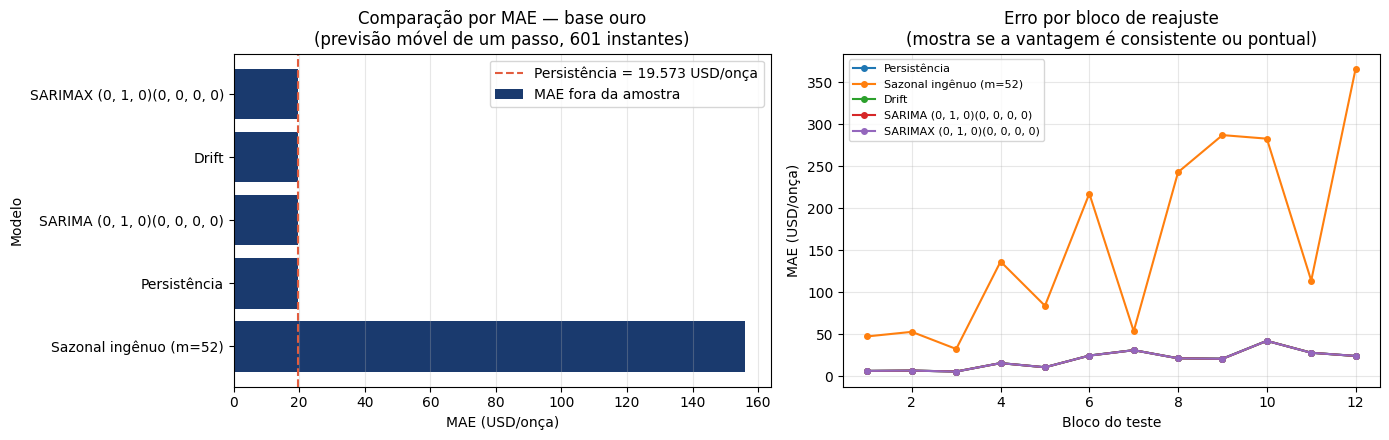

In [19]:
# ---------- consolidação: MAE por base e modelo, vitórias e posição média ----------
previsoes_modelos[f"SARIMAX {ORDER}{SEASONAL_ORDER}"] = (
    wf.set_index("data")["previsto"].reindex(idx_comum)
)

painel = pd.DataFrame(previsoes_modelos, index=idx_comum)
comparacao = pd.DataFrame([resumir_erros(nome, painel[nome]) for nome in painel.columns])

# Vitórias e posição média por bloco de reajuste: o ranking global diz quem é o
# melhor na média, mas não quão consistente ele é ao longo do teste.
erros_abs = painel.sub(real_comum, axis=0).abs()
bloco_de = wf.set_index("data")["bloco"].reindex(idx_comum)
mae_por_bloco = erros_abs.groupby(bloco_de).mean()
rank_por_bloco = mae_por_bloco.rank(axis=1, method="min")

comparacao = comparacao.merge(
    pd.DataFrame({
        "vitorias": (rank_por_bloco == 1).sum(),
        "blocos": len(rank_por_bloco),
        "posicao_media": rank_por_bloco.mean(),
    }).rename_axis("modelo").reset_index(),
    on="modelo",
)
comparacao["posicao_MAE_global"] = comparacao["MAE"].rank(method="min").astype(int)

mae_persistencia = comparacao.loc[
    comparacao["modelo"] == "Persistência", "MAE"
].iloc[0]
comparacao["ganho_sobre_persistencia_pct"] = 100 * (1 - comparacao["MAE"] / mae_persistencia)
comparacao = comparacao.sort_values("MAE").reset_index(drop=True)
display(comparacao.round(4))

vencedor = comparacao.iloc[0]
print(f"\nMenor MAE: {vencedor['modelo']} com {vencedor['MAE']:.4f} {UNIDADE} "
      f"em {len(idx_comum):,} previsões de um passo.")
print(f"Vitórias por bloco: {vencedor['vitorias']} de {vencedor['blocos']} | "
      f"posição média {vencedor['posicao_media']:.2f}")
print("As métricas acima são recalculadas no índice comum e podem diferir das da "
      "célula anterior, que usa todas as previsões do SARIMAX.")

fig, (eixo_mae, eixo_blocos) = plt.subplots(1, 2, figsize=(14, 4.5))
eixo_mae.barh(comparacao["modelo"], comparacao["MAE"], color="#1a3a6e",
              label="MAE fora da amostra")
eixo_mae.axvline(mae_persistencia, color="#e25c3e", linestyle="--",
                 label=f"Persistência = {mae_persistencia:.3f} {UNIDADE}")
eixo_mae.set_title(f"Comparação por MAE — base {BASE_NAME}\n"
                   f"(previsão móvel de um passo, {len(idx_comum):,} instantes)")
eixo_mae.set_xlabel(f"MAE ({UNIDADE})")
eixo_mae.set_ylabel("Modelo")
eixo_mae.invert_yaxis()
eixo_mae.legend()
eixo_mae.grid(axis="x", alpha=0.3)

for nome in mae_por_bloco.columns:
    eixo_blocos.plot(mae_por_bloco.index, mae_por_bloco[nome],
                     marker="o", markersize=4, label=nome)
eixo_blocos.set_title("Erro por bloco de reajuste\n"
                      "(mostra se a vantagem é consistente ou pontual)")
eixo_blocos.set_xlabel("Bloco do teste")
eixo_blocos.set_ylabel(f"MAE ({UNIDADE})")
eixo_blocos.legend(fontsize=8)
eixo_blocos.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## T17 — Diagnóstico dos resíduos

Análise gráfica e estatística dos resíduos com série temporal dos erros, ACF, teste de Ljung-Box e tabela de p-valores.

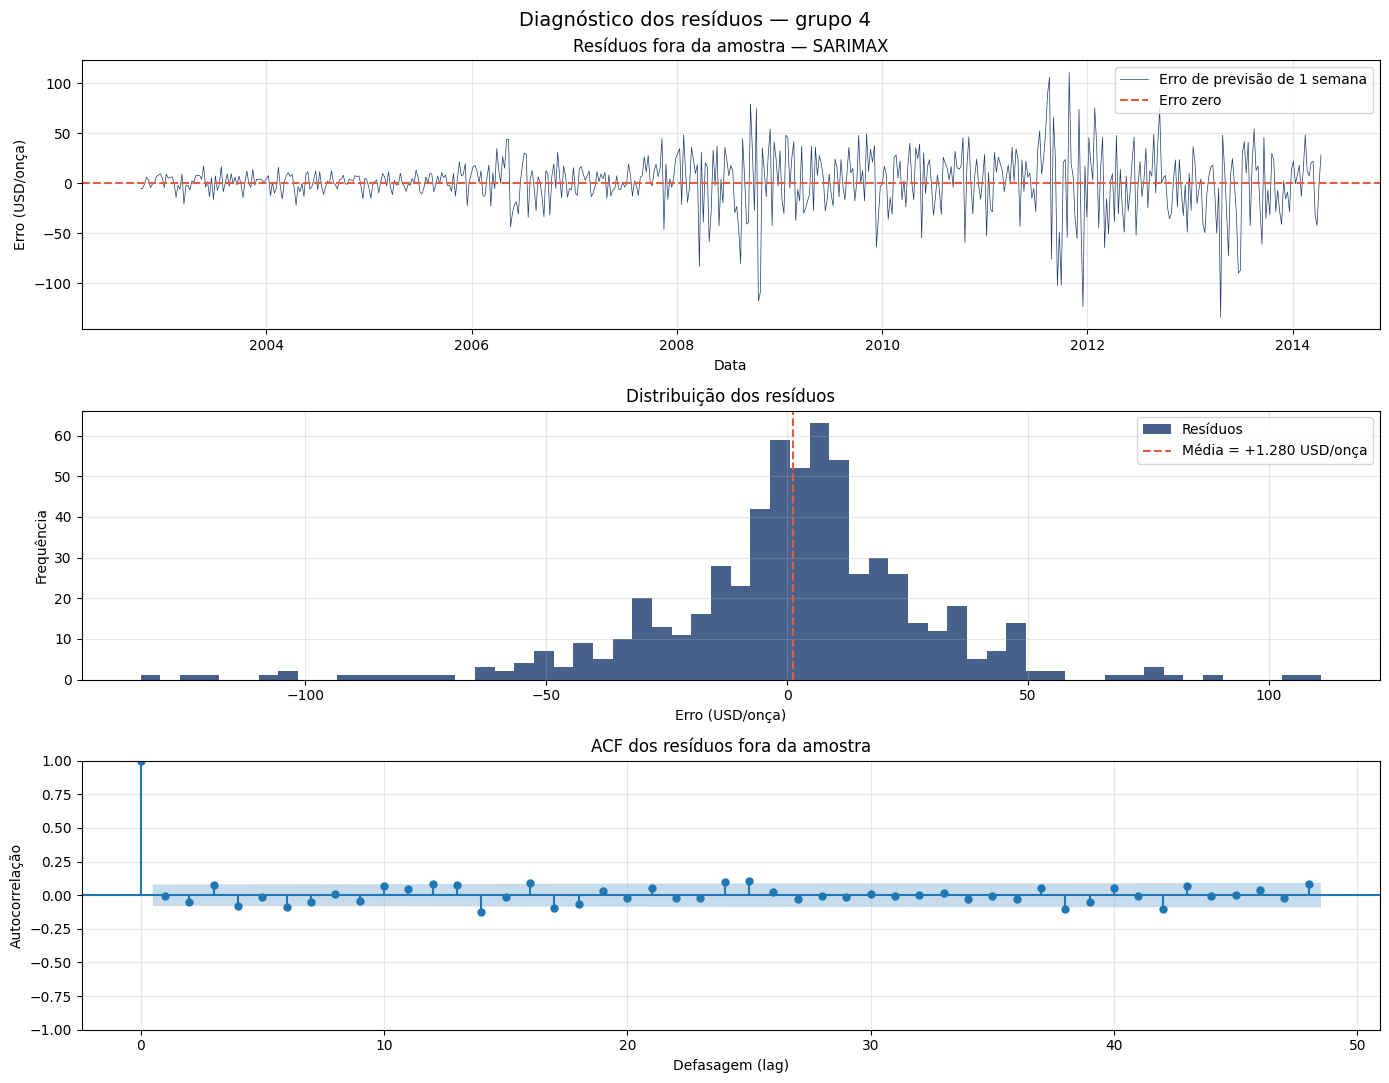

,lb_stat,lb_pvalue
1,0.050904,0.821497
2,1.650719,0.438077
3,5.321974,0.149683
4,9.016214,0.060695
5,9.126417,0.104127
6,13.703094,0.033134
7,15.408050,0.031110
8,15.425705,0.051378
9,16.564442,0.055990
10,19.561841,0.033680


Viés médio: +1.2801 USD/onça | desvio-padrão: 27.9771 USD/onça
O resíduo é real menos previsto: ME < 0 indica superestimação média, ME > 0 indica subestimação média.
Ljung-Box: há autocorrelação residual (p < 0,05). Com horizonte de um passo os resíduos deveriam ser ruído branco, então a rejeição indica estrutura temporal que a ordem escolhida não capturou. Vale ler junto com a ACF: autocorrelação em lags múltiplos de 52 aponta sazonalidade residual.


In [20]:
# T17 — diagnóstico dos resíduos fora da amostra
residuos_teste = wf.set_index("data")["residuo"]
fig, axes = plt.subplots(3, 1, figsize=(14, 11))
axes[0].plot(residuos_teste.index, residuos_teste.to_numpy(), color="#1a3a6e",
             linewidth=0.5, label="Erro de previsão de 1 semana")
axes[0].axhline(0, color="#e25c3e", linestyle="--", label="Erro zero")
axes[0].set_title("Resíduos fora da amostra — SARIMAX")
axes[0].set_xlabel("Data")
axes[0].set_ylabel("Erro (USD/onça)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuos_teste.to_numpy(), bins=60, alpha=0.8, color="#1a3a6e",
             label="Resíduos")
axes[1].axvline(residuos_teste.mean(), color="#e25c3e", linestyle="--",
                label=f"Média = {residuos_teste.mean():+.3f} USD/onça")
axes[1].set_title("Distribuição dos resíduos")
axes[1].set_xlabel("Erro (USD/onça)")
axes[1].set_ylabel("Frequência")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plot_acf(residuos_teste, lags=48, ax=axes[2],
         title="ACF dos resíduos fora da amostra")
axes[2].set_xlabel("Defasagem (lag)")
axes[2].set_ylabel("Autocorrelação")
axes[2].grid(True, alpha=0.3)

fig.suptitle("Diagnóstico dos resíduos — grupo 4", fontsize=14)
plt.tight_layout()
plt.show()

analise_residuos_teste = analisar_componente_residual(
    type("Decomposicao", (), {"resid": residuos_teste})(), lags=24
)
ljung_box = analise_residuos_teste["autocorrelacao_residual"]
display(ljung_box)
print(f"Viés médio: {residuos_teste.mean():+.4f} USD/onça | "
      f"desvio-padrão: {residuos_teste.std():.4f} USD/onça")
print("O resíduo é real menos previsto: ME < 0 indica superestimação média, "
      "ME > 0 indica subestimação média.")
if (ljung_box["lb_pvalue"] < 0.05).any():
    print("Ljung-Box: há autocorrelação residual (p < 0,05). Com horizonte de um "
          "passo os resíduos deveriam ser ruído branco, então a rejeição indica "
          "estrutura temporal que a ordem escolhida não capturou. Vale ler junto "
          "com a ACF: autocorrelação em lags múltiplos de 52 aponta sazonalidade "
          "residual.")
else:
    print("Ljung-Box: não houve rejeição de ruído branco nos lags avaliados, "
          "o que é o esperado para previsão de um passo bem especificada.")


## T18 — Importância das features

Cálculo e interpretação da importância das features: permutation importance para modelos de tabela e coeficientes para o SARIMAX.

,variavel,coeficiente,p_valor,importancia_absoluta,signif_5pct
1,dia_ano_cos,0.013651,0.078228,0.013651,False
0,dia_ano_sin,0.001343,0.865899,0.001343,False


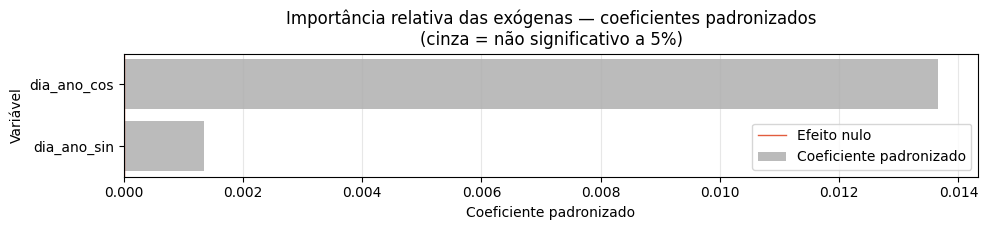

Como as exógenas foram padronizadas, o coeficiente é o efeito em desvios-padrão do alvo por desvio-padrão da variável, e os valores são comparáveis entre si. Os termos autorregressivos não aparecem nesta tabela: com horizonte de uma semana, a maior parte da previsão vem deles, e não das exógenas.


In [21]:
# T18 — coeficientes das exógenas padronizadas
# Os coeficientes vêm do último reajuste da T16, guardado antes de o objeto de
# resultados ser descartado. O ajuste usa arrays para tolerar as lacunas do
# calendário, então o statsmodels nomeia as exógenas como x1, x2, ... A tabela
# abaixo traduz de volta para os nomes das colunas.
nomes_statsmodels = [f"x{i}" for i in range(1, X_train.shape[1] + 1)]

coeficientes = pd.DataFrame({
    "variavel": X_train.columns,
    "coeficiente": [coeficientes_finais.get(nome, np.nan) for nome in nomes_statsmodels],
    "p_valor": [pvalores_finais.get(nome, np.nan) for nome in nomes_statsmodels],
})
coeficientes["importancia_absoluta"] = coeficientes["coeficiente"].abs()
coeficientes["signif_5pct"] = coeficientes["p_valor"] < 0.05
coeficientes = coeficientes.sort_values("importancia_absoluta", ascending=False)
display(coeficientes.round(6))

fig, ax = plt.subplots(figsize=(10, 0.45 * len(coeficientes) + 1.5))
cores = ["#1a3a6e" if s else "#bbbbbb" for s in coeficientes["signif_5pct"]]
ax.barh(coeficientes["variavel"], coeficientes["coeficiente"], color=cores,
        label="Coeficiente padronizado")
ax.axvline(0, color="#e25c3e", lw=1, label="Efeito nulo")
ax.set_title("Importância relativa das exógenas — coeficientes padronizados\n"
             "(cinza = não significativo a 5%)")
ax.set_xlabel("Coeficiente padronizado")
ax.set_ylabel("Variável")
ax.legend(loc="lower right")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Como as exógenas foram padronizadas, o coeficiente é o efeito em desvios-"
      "padrão do alvo por desvio-padrão da variável, e os valores são comparáveis "
      "entre si. Os termos autorregressivos não aparecem nesta tabela: com "
      "horizonte de uma semana, a maior parte da previsão vem deles, e não das "
      "exógenas.")
if not ajuste_convergiu:
    print("Atenção: o último reajuste não convergiu dentro do limite de iterações. "
          "Os p-valores vêm da matriz de informação avaliada no ponto em que o "
          "otimizador parou, e devem ser lidos como indicativos, não como teste "
          "formal.")


Matriz T06 (ouro): 2,376 linhas x 17 features | máscara idêntica à da T08: sim
Exógenas da T06 idênticas às usadas no SARIMAX (T08): ok
Último bloco: 2013-07-12 00:00:00 a 2014-04-11 00:00:00 (40 h) | estimado em 2,336 obs
MAE do bloco recalculado: 24.0558 USD/onça | MAE do bloco na T16: 24.0558 USD/onça | diferença: 0.00e+00
Avaliação de um conjunto de features: 0 s | 3 avaliações previstas: ~0 min


,grupo,colunas,MAE_base,MAE_permutado,importancia_MAE,desvio_importancia,aumento_pct
0,dia do ano,"dia_ano_sin, dia_ano_cos",24.0558,24.5397,0.4839,0.9474,2.0117


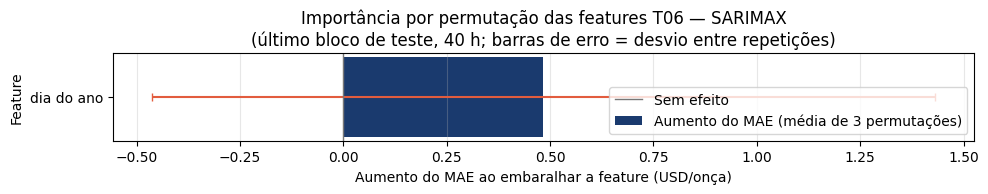

Embaralhar uma feature dentro do bloco, com os parâmetros congelados, mede quanto a previsão de uma semana piora sem a informação dela; valores próximos de zero indicam que o modelo quase não depende da feature. A medida cobre só as exógenas: os termos AR/MA, que carregam a maior parte da previsão a uma semana, não são permutados. Sem reajuste, features correlacionadas podem dividir ou superestimar a importância, e o resultado descreve o último bloco, não o teste inteiro.
Tempo da T19: 0.0 min


In [22]:
# T19 — importância por permutação das features temporais (módulo T06) no SARIMAX

tempo_t19 = time.perf_counter()
N_REPETICOES = 3

# ---------- 1. as funções da T06 reproduzem o que a T08 já usou ----------
# (a) mesma máscara de elegibilidade, agora vinda de preparar_features_base;
# (b) mesmas exógenas do SARIMAX, agora vindas de construir_features_temporais.
matriz_t06 = ft.preparar_features_base(
    df, BASE_NAME, TARGET_COLUMN, FREQUENCY, remover_incompletos=True
)
mascara_igual = matriz_t06.index.equals(elegibilidade)
print(f"Matriz T06 ({BASE_NAME}): {matriz_t06.shape[0]:,} linhas x "
      f"{matriz_t06.shape[1] - 1} features | máscara idêntica à da T08: "
      f"{'sim' if mascara_igual else 'NÃO'}")

COLUNAS_T06 = list(X_train.columns.str.replace(
    f"_lag{EXOG_LAG}", f"_lag_{EXOG_LAG}", regex=False))
X_t06 = ft.construir_features_temporais(
    df, TARGET_COLUMN,
    lags_alvo=[EXOG_LAG],
    lags_exogenas={c: [EXOG_LAG] for c in EXOG_COLUMNS},
    janelas_moveis=[],
    calendario=tuple(CALENDARIO),
    indicadores_conhecidos=INDICADORES_CONHECIDOS,
    horizonte=HORIZON,
    frequencia=FREQUENCY,
)[COLUNAS_T06]
X_modelo = pd.concat([X_train, X_test])
X_t06 = X_t06.loc[X_modelo.index]
if not np.allclose(X_t06.to_numpy(), X_modelo.to_numpy()):
    raise ValueError("As features da T06 diferem das exógenas usadas pelo SARIMAX.")
print("Exógenas da T06 idênticas às usadas no SARIMAX (T08): ok")

# Variáveis que são o mesmo sinal em seno/cosseno entram e saem juntas.
GRUPOS = {
    "dia do ano": ["dia_ano_sin", "dia_ano_cos"],
}

# ---------- 2. refiltra o último bloco da T16 com os parâmetros congelados ----------
# Nada é reestimado: os parâmetros são os de coeficientes_finais (último reajuste
# da T16). O método é o mesmo da T16, append(..., refit=False): é ele que garante
# previsões idênticas às já reportadas. Cada avaliação refiltra a janela inteira
# mais o bloco, então o custo é o de um append da T16 por permutação.
inicio_u, fim_u = blocos[-1]
y_hist_u = pd.concat([y_train, y_test.iloc[:inicio_u]])
if JANELA_REFIT is not None:
    y_hist_u = y_hist_u.iloc[-JANELA_REFIT:]
X_hist_u = X_t06.loc[y_hist_u.index]
y_bloco_u = y_test.iloc[inicio_u:fim_u]
X_bloco_u = X_t06.loc[y_bloco_u.index]

sc_y_u, sc_x_u = StandardScaler(), StandardScaler()
y_hist_sc_u = sc_y_u.fit_transform(y_hist_u.to_numpy().reshape(-1, 1)).ravel()
X_hist_sc_u = sc_x_u.fit_transform(X_hist_u.to_numpy())
y_bloco_sc_u = sc_y_u.transform(y_bloco_u.to_numpy().reshape(-1, 1)).ravel()

modelo_u = SARIMAX(
    y_hist_sc_u, exog=X_hist_sc_u, order=ORDER, seasonal_order=SEASONAL_ORDER,
    trend=TREND,
    enforce_stationarity=ENFORCE_STATIONARITY,
    enforce_invertibility=ENFORCE_INVERTIBILITY,
    concentrate_scale=CONCENTRATE_SCALE,
)
estado_u = modelo_u.filter(coeficientes_finais.to_numpy())


def _mae_bloco(X_df):
    """MAE (USD/onça) de uma semana à frente no último bloco, dadas as exógenas X_df."""
    ext = estado_u.append(y_bloco_sc_u, exog=sc_x_u.transform(X_df.to_numpy()),
                          refit=False)
    prev_sc = np.asarray(ext.get_prediction(
        start=len(y_hist_sc_u), end=len(y_hist_sc_u) + len(y_bloco_sc_u) - 1,
        dynamic=False
    ).predicted_mean)
    del ext
    prev = sc_y_u.inverse_transform(prev_sc.reshape(-1, 1)).ravel()
    return float(np.abs(y_bloco_u.to_numpy() - prev).mean())


inicio_base = time.perf_counter()
mae_base_u = _mae_bloco(X_bloco_u)
segundos_avaliacao = time.perf_counter() - inicio_base
mae_ref_u = float(wf.loc[wf["bloco"] == len(blocos), "residuo"].abs().mean())
print(f"Último bloco: {y_bloco_u.index[0]} a {y_bloco_u.index[-1]} "
      f"({len(y_bloco_u):,} h) | estimado em {len(y_hist_u):,} obs")
print(f"MAE do bloco recalculado: {mae_base_u:.4f} USD/onça | MAE do bloco na T16: "
      f"{mae_ref_u:.4f} USD/onça | diferença: {abs(mae_base_u - mae_ref_u):.2e}")
if abs(mae_base_u - mae_ref_u) > 1e-4:
    print("Atenção: o MAE recalculado não bate com o da T16; a importância "
          "abaixo não deve ser lida antes de se entender a diferença.")

# ---------- 3. permutação ----------
print(f"Avaliação de um conjunto de features: {segundos_avaliacao:.0f} s | "
      f"{len(GRUPOS) * N_REPETICOES} avaliações previstas: "
      f"~{len(GRUPOS) * N_REPETICOES * segundos_avaliacao / 60:.0f} min")
rng_u = np.random.default_rng(SEED)
linhas = []
for nome, colunas in GRUPOS.items():
    maes = []
    for _ in range(N_REPETICOES):
        permutacao = rng_u.permutation(len(X_bloco_u))
        X_perm = X_bloco_u.copy()
        X_perm[colunas] = X_bloco_u[colunas].to_numpy()[permutacao]
        maes.append(_mae_bloco(X_perm))
    linhas.append({
        "grupo": nome,
        "colunas": ", ".join(colunas),
        "MAE_base": mae_base_u,
        "MAE_permutado": np.mean(maes),
        "importancia_MAE": np.mean(maes) - mae_base_u,
        "desvio_importancia": np.std(maes, ddof=1),
        "aumento_pct": 100 * (np.mean(maes) / mae_base_u - 1),
    })
importancia_perm = (
    pd.DataFrame(linhas).sort_values("importancia_MAE", ascending=False)
    .reset_index(drop=True)
)
display(importancia_perm.round(4))

fig, ax = plt.subplots(figsize=(10, 0.55 * len(importancia_perm) + 1.5))
ax.barh(importancia_perm["grupo"], importancia_perm["importancia_MAE"],
        xerr=importancia_perm["desvio_importancia"], color="#1a3a6e",
        ecolor="#e25c3e", capsize=3,
        label=f"Aumento do MAE (média de {N_REPETICOES} permutações)")
ax.axvline(0, color="#777777", lw=1, label="Sem efeito")
ax.set_title("Importância por permutação das features T06 — SARIMAX\n"
             f"(último bloco de teste, {len(y_bloco_u):,} h; barras de erro = "
             "desvio entre repetições)")
ax.set_xlabel("Aumento do MAE ao embaralhar a feature (USD/onça)")
ax.set_ylabel("Feature")
ax.legend(loc="lower right")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Embaralhar uma feature dentro do bloco, com os parâmetros congelados, "
      "mede quanto a previsão de uma semana piora sem a informação dela; valores "
      "próximos de zero indicam que o modelo quase não depende da feature. A "
      "medida cobre só as exógenas: os termos AR/MA, que carregam a maior parte "
      "da previsão a uma semana, não são permutados. Sem reajuste, features "
      "correlacionadas podem dividir ou superestimar a importância, e o "
      "resultado descreve o último bloco, não o teste inteiro.")

del estado_u, modelo_u, y_hist_sc_u, X_hist_sc_u
gc.collect()
print(f"Tempo da T19: {(time.perf_counter() - tempo_t19) / 60:.1f} min")
